# Schedule Visit Projection and Completion Forecasting for a Longitudinal Research Study
## Machine-Learning Forecasting Module — 36-Month Visit Projection

**Notebook:** `ML.ipynb`  ·  **Input:** `36m_Projections(36m Projections).csv`  ·  **Unit of analysis:** participant → *36-Month* visit event

---

### What this notebook is

This is the **forecasting engine** for the study's operational scheduling workflow. It takes the roster of
participants whose **36-Month** visit is anticipated, reconstructs the monthly visit-volume time series, and
answers a single planning question with defensible numbers:

> **How many 36-Month visits should the lab expect to staff, month by month, over the next 36 months —
> and how confident can we be in each figure?**

It does this by fitting a **ladder of candidate models** — from transparent count baselines to statistical
time-series models to tree-based machine-learning regressors — then **ranking them by honest, leakage-free
back-testing** rather than by which produces the prettiest curve. The winning model is combined with a
**deterministic recruitment-pipeline projection** to produce a base / low / high forecast with explicit
uncertainty.

> **Reading guide.** Every modelling choice below is justified against *this* dataset's measured properties
> (sample size, dispersion, autocorrelation, censoring). The notebook is written so a statistician can audit
> the method and a coordinator can act on the output table. Where the data do not support a complex model,
> the notebook says so and uses the simpler one — that is the correct scientific result, not a shortcut.

## 1. Operational questions this notebook answers

1. **Volume:** How many 36-Month visits are expected in each of the next 36 months?
2. **Peaks:** Which months carry the heaviest visit workload (staffing pinch-points)?
3. **Seasonality:** Is there a recurring month-of-year pattern the lab can plan around?
4. **Uncertainty:** What is a realistic *low* and *high* band around each monthly figure?
5. **Model trust:** Which forecasting method actually predicts best on held-out history, and by how much does it beat a naive guess?
6. **Data integrity:** Does the roster contain errors (bad dates, duplicate IDs, an internally inconsistent summary) that would corrupt the forecast?
7. **Pipeline reality:** How much of the far-horizon forecast depends on participants **not yet enrolled**, and should therefore be read as a recruitment assumption rather than a fixed booking?

**Scope and honesty statement.** This is *decision support*, not a guarantee. The output is a **protocol- and
history-based expectation of visit volume**, not a promise that each visit occurs. It is **not** a causal model
and **not** a black-box prediction: every number is traceable to an input row or a stated assumption. Where the
sample is too small to justify a method, the notebook falls back to the simpler, more robust estimator and
records why.

## 2. Theory and conceptual framework

### 2.1 What kind of quantity are we forecasting?

The target is a **monthly count of visit events** — a non-negative integer per calendar month. Count series
have three properties that dictate the right modelling family:

- **Non-negativity & discreteness.** A Gaussian model can predict −2 visits; a count model cannot. The natural
  likelihood is **Poisson** (mean = variance) or, when the spread exceeds the mean, **Negative Binomial**
  (over-dispersed).
- **Dispersion.** We measure the *dispersion ratio* $D = \mathrm{Var}(y)/\mathrm{E}(y)$. $D \approx 1$ →
  Poisson is appropriate; $D \gg 1$ → Negative Binomial; $D < 1$ → under-dispersed (Poisson intervals are
  conservatively wide, which is acceptable for staffing).
- **Small-sample fragility.** With only a few dozen usable months, a model's *variance* (sensitivity to the
  particular sample) dominates its *bias*. This is the **bias–variance trade-off**: flexible models
  (SARIMA with many terms, gradient boosting) can fit the training months almost perfectly yet forecast worse
  than a flat mean, because they memorise noise. The antidote is **out-of-sample back-testing**, never
  in-sample fit.

### 2.2 Deterministic projection vs. statistical forecasting

We use **two complementary engines** and keep them clearly separated:

| | **Deterministic recruitment-pipeline projection** | **Statistical / ML forecast** |
|---|---|---|
| Basis | Each already-enrolled participant has a *scheduled* 36-Month appointment date → count directly | Learns the historical monthly rate & pattern, projects it forward |
| Strength | Exact for the near horizon (people already in the pipeline) | Extends beyond the known pipeline; supplies uncertainty |
| Weakness | Blind to participants not yet enrolled; far horizon empty | Assumes the past process continues; sensitive to small $n$ |
| Role here | **Primary** for months already populated by the roster | **Primary** for the far horizon + all uncertainty bands |

> **Why deterministic is primary where it applies.** When a visit's date is already written down, forecasting it
> is silly — you *count* it. Statistical modelling earns its keep only past the edge of the known pipeline, and
> for quantifying how wrong the counts might be.

### 2.3 The censoring problem (critical for this dataset)

The roster is a **snapshot**. Participants enrolled recently have their 36-Month visit far in the future; that
future is populated. But **participants who will enrol next year are not in the file yet**, so the last several
months of the horizon look artificially empty — they are **right-censored**, not genuinely low-volume.

Fitting a trend straight through the tail would "discover" a fake decline. The notebook therefore:

1. **Detects the censoring boundary** (the last month with a mature, trustworthy count),
2. **Fits models only on mature months**, and
3. **Flags censored months** so their apparent emptiness is never mistaken for a real drop.

### 2.4 Seasonality, trend, and autocorrelation

- **Trend** — a systematic drift in monthly volume. Tested with a rank correlation of count vs. time.
- **Seasonality** — a recurring month-of-year effect (e.g. an August peak arising from a birth-month cohort 36 months earlier).
- **Autocorrelation** — whether this month's count helps predict next month's. Quantified with the **ACF/PACF**;
  values inside the $\pm 1.96/\sqrt{n}$ band are statistically indistinguishable from zero, which means
  **AR/MA memory models add nothing** and a rate-based model is preferred.

### 2.5 Probability-adjusted completion (secondary layer)

Projected ≠ completed. If historical completion behaviour were available, the expected number of *completed*
visits in a period would be

$$\mathbb{E}[\text{completed}] \;=\; \sum_{v \in \text{projected}} p_{t(v)},$$

where $p_{t(v)}$ is the empirically estimated completion probability for the visit's timepoint. This file carries
**projected** 36-Month visits only (no completed/no-show outcomes), so completion probabilities cannot be
estimated from it. The notebook **exposes a single `COMPLETION_RATE` lever** so the lab can convert expected
visits into expected completions once outcome data exist, and it explicitly declines to invent a rate. This keeps
the estimate **descriptive and probabilistic**, never presented as a causal or ML-validated certainty.

### 2.6 Why not "just use a neural network / AutoML"?

With a few dozen monthly observations, no autocorrelation, and a known censoring artefact, high-capacity models
**cannot** be validated — there is not enough held-out data to distinguish skill from luck, and they silently
extrapolate the censoring bias. The scientifically correct answer is a **well-specified simple model with honest
intervals**. An advanced-model slot is included in the appendix with the prerequisites it would require, but is
**not** used for the headline forecast.

### 2.7 Ethics & privacy

Participant IDs are pseudonymous but still identifiable in aggregate with dates. This notebook: (a) works only
with ID + date + visit-label — **no names, contact details, or clinical content**; (b) keeps identifiable
participant-level tables as **restricted** exports; and (c) puts **only aggregate counts** into charts and any
shareable output.

## 3. Setup and reproducibility

The cell below is the **only place you edit before running**. It fixes paths, a single random seed, display
options, and the study-specific levers (window rules, forecast horizon, the model set, and the completion-rate
lever discussed in §2.5). Everything downstream reads from this `CFG` object, so the notebook runs top-to-bottom
with no further code edits.

In [1]:
# === 3.1  Imports, seed, display ===================================================
from __future__ import annotations
import os, sys, json, warnings, platform, hashlib
from datetime import datetime, date
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")           # keep the narrative clean; QC is explicit below
SEED = 20260723                              # single global seed for every stochastic step
np.random.seed(SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", mpl.__version__)
print("random seed :", SEED)

Python      : 3.12.13
pandas      : 3.0.3
numpy       : 2.5.1
matplotlib  : 3.11.1
random seed : 20260723


In [2]:
# === 3.2  Colourblind-safe palette (from the lab's data-viz standard) =============
# Fixed hue order; assigned by identity, never cycled. Used consistently in every chart.
PALETTE = {
    "blue":    "#2a78d6",  "orange": "#eb6834",  "aqua":   "#1baf7a",  "yellow": "#eda100",
    "magenta": "#e87ba4",  "green":  "#008300",  "violet": "#4a3aa7",  "red":    "#e34948",
}
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK        = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#898781"
GRID       = "#e1e0d9"; SURFACE = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "figure.dpi": 110, "savefig.dpi": 200,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
})

def style_axes(ax):
    """Recessive chrome: drop top/right spines, thin the rest, horizontal-only grid."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_linewidth(0.8)
    ax.grid(axis="x", visible=False)
    return ax
print("palette + matplotlib theme configured")

palette + matplotlib theme configured


In [3]:
# === 3.3  Study configuration — EDIT HERE ONLY ====================================
@dataclass
class Config:
    # ---- Paths (relative to this notebook's folder) ----
    input_csv: str   = "36m_Projections(36m Projections).csv"
    output_dir: str  = "ml_forecast_outputs"

    # ---- Study identity / provenance ----
    study_name: str  = "Longitudinal Infant/Autism Study — 36-Month Visit Track"
    refresh_date: str = ""            # "" -> use today; else "YYYY-MM-DD"
    visit_label: str = "36 Months"    # the single timepoint present in this export

    # ---- Column mapping (confirmed against the audit in §4; do not assume) ----
    col_pid:   str = "participant_id"
    col_appt:  str = "appointment_date"
    col_visit: str = "visit"
    appt_date_format: str = "%d-%b-%y"    # e.g. 05-May-26

    # ---- Forecast controls ----
    horizon_months: int   = 36            # forecast horizon
    census_min_count: int = 0             # set >0 to override auto censoring detection
    n_backtest_folds: int = 6             # rolling-origin CV folds
    backtest_horizon: int = 6             # months ahead scored per fold (multi-step, matches use)
    min_train_months: int = 12            # smallest training window a fold may use

    # ---- Scheduling-window rules (calendar days around the ideal/appointment date) ----
    window_early_days: int = 30
    window_late_days:  int = 60
    due_soon_days:     int = 60
    overdue_grace_days: int = 30

    # ---- Completion lever (see §2.5). None -> report projected visits only, no invented rate ----
    completion_rate: float | None = None      # e.g. 0.85 once outcome data exist
    completion_low:  float | None = None      # optional scenario band
    completion_high: float | None = None

    # ---- Which models to fit (toggle without touching code) ----
    models: tuple = ("mean", "seasonal_naive", "poisson_glm", "negbin_glm",
                     "ets", "sarima", "random_forest", "grad_boost")

CFG = Config()
if not CFG.refresh_date:
    CFG.refresh_date = date.today().isoformat()
REFRESH = pd.Timestamp(CFG.refresh_date)
print("Configuration loaded. Refresh date:", CFG.refresh_date)

Configuration loaded. Refresh date: 2026-07-23


In [4]:
# === 3.4  Output folder, run log, input-file metadata =============================
os.makedirs(CFG.output_dir, exist_ok=True)
FIG_DIR = os.path.join(CFG.output_dir, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

def file_fingerprint(path):
    """Return size, mtime and a short content hash for provenance/auditability."""
    if not os.path.exists(path):
        return {"exists": False, "path": path}
    with open(path, "rb") as fh:
        h = hashlib.sha256(fh.read()).hexdigest()[:16]
    st = os.stat(path)
    return {"exists": True, "path": os.path.abspath(path),
            "size_bytes": st.st_size,
            "modified": datetime.fromtimestamp(st.st_mtime).isoformat(timespec="seconds"),
            "sha256_16": h}

RUN_LOG = {
    "study": CFG.study_name,
    "refresh_date": CFG.refresh_date,
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "seed": SEED,
    "input_file": file_fingerprint(CFG.input_csv),
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in asdict(CFG).items()},
    "warnings": [],
}
def log_warn(msg):
    RUN_LOG["warnings"].append(msg)
    print("  ⚠", msg)

print("Output dir :", os.path.abspath(CFG.output_dir))
print("Input file :", RUN_LOG["input_file"].get("path"))
print("Input hash :", RUN_LOG["input_file"].get("sha256_16"), "| size",
      RUN_LOG["input_file"].get("size_bytes"), "bytes")
if not RUN_LOG["input_file"]["exists"]:
    log_warn("Input CSV not found — update CFG.input_csv before running the rest of the notebook.")

Output dir : /Users/namomac/esd-redcap-metadata-watcher/ML Predictions/ml_forecast_outputs
Input file : /Users/namomac/esd-redcap-metadata-watcher/ML Predictions/36m_Projections(36m Projections).csv
Input hash : 18fe9ba6758440ce | size 6275 bytes


## 4. Data import and initial audit

This export is **not a tidy rectangle** — it is three tables side-by-side in one sheet:

- **Block A** (cols 1–3): the participant roster — `participant_id`, `appointment_date`, `visit`. *One row per participant.* This is the modelling source.
- **Block B** (cols 5–6): a pre-computed **month → count** summary someone built by hand.
- **Block C** (cols 8–9): a pre-computed **year → count** summary.

We import Block A as the authoritative source and keep Blocks B and C **only to audit them against a
recomputation** — hand-built summaries are exactly where transcription errors hide. We assume nothing about
column names: the raw grid is read first, then mapped.

In [5]:
# === 4.1  Raw read (no header assumptions) ========================================
raw = pd.read_csv(CFG.input_csv, header=None, dtype=str)
print("Raw grid shape:", raw.shape)
print("\nNon-null cells per raw column:")
print(raw.notna().sum().to_string())
print("\nFirst 3 raw rows:")
print(raw.head(3).to_string())

Raw grid shape: (187, 9)

Non-null cells per raw column:
0    187
1    187
2    187
3      0
4     35
5     35
6      0
7      4
8      4

First 3 raw rows:
                         0                 1          2    3       4    5    6     7    8
0  Participant Information  Appointment Date      Visit  NaN     NaN  NaN  NaN   NaN  NaN
1                     5005         05-May-26  36 Months  NaN  May-26    1  NaN  2026   44
2                     5034         04-Jun-26  36 Months  NaN  Jun-26    8  NaN  2027   72


In [6]:
# === 4.2  Split the three blocks ==================================================
# Header lives in row 0. Block boundaries are the empty separator columns (all-NaN).
header = raw.iloc[0].tolist()
print("Row-0 labels:", header)

# Block A: participant roster (first 3 populated columns)
roster = raw.iloc[1:, [0, 1, 2]].copy()
roster.columns = [CFG.col_pid, CFG.col_appt, CFG.col_visit]
roster = roster.dropna(subset=[CFG.col_pid]).reset_index(drop=True)

# Block B: month summary (cols 4,5) — kept for audit only
file_month_summary = raw.iloc[1:, [4, 5]].copy()
file_month_summary.columns = ["month", "count"]
file_month_summary = file_month_summary.dropna(subset=["month"]).reset_index(drop=True)

# Block C: year summary (cols 7,8) — kept for audit only
file_year_summary = raw.iloc[1:, [7, 8]].copy()
file_year_summary.columns = ["year", "count"]
file_year_summary = file_year_summary.dropna(subset=["year"]).reset_index(drop=True)

print(f"\nBlock A (roster)       : {roster.shape[0]} participant rows")
print(f"Block B (month summary): {file_month_summary.shape[0]} rows  (audit only)")
print(f"Block C (year summary) : {file_year_summary.shape[0]} rows  (audit only)")
roster.head()

Row-0 labels: ['Participant Information', 'Appointment Date', 'Visit', nan, nan, nan, nan, nan, nan]

Block A (roster)       : 186 participant rows
Block B (month summary): 35 rows  (audit only)
Block C (year summary) : 4 rows  (audit only)


,participant_id,appointment_date,visit
0,5005,05-May-26,36 Months
1,5034,04-Jun-26,36 Months
2,5035,04-Jun-26,36 Months
3,5011,07-Jun-26,36 Months
4,5016,09-Jun-26,36 Months


In [7]:
# === 4.3  Types, sample, missingness ==============================================
print("Dtypes (as read):")
print(roster.dtypes.to_string())
print("\nSample rows:")
print(roster.sample(min(6, len(roster)), random_state=SEED).to_string(index=False))
print("\nMissingness by field:")
miss = pd.DataFrame({
    "n_missing": roster.isna().sum(),
    "pct_missing": (roster.isna().mean() * 100).round(2),
})
print(miss.to_string())

Dtypes (as read):
participant_id      str
appointment_date    str
visit               str

Sample rows:
participant_id appointment_date     visit
          5101        29-Aug-27 36 Months
          5215        17-Feb-29 36 Months
          5070        24-Dec-26 36 Months
          5015        11-Nov-26 36 Months
          5027        04-Oct-26 36 Months
          5170        03-Mar-28 36 Months

Missingness by field:
                  n_missing  pct_missing
participant_id            0          0.0
appointment_date          0          0.0
visit                     0          0.0


In [8]:
# === 4.4  Parse + validate: dates, IDs, duplicates, impossible sequences ==========
audit = {}

# Parse appointment date and participant id
roster["_appt_dt"] = pd.to_datetime(roster[CFG.col_appt], format=CFG.appt_date_format, errors="coerce")
roster["_pid_num"] = pd.to_numeric(roster[CFG.col_pid], errors="coerce")

audit["bad_dates"]      = int(roster["_appt_dt"].isna().sum())
audit["bad_ids"]        = int(roster["_pid_num"].isna().sum())
audit["dup_pid"]        = int(roster[CFG.col_pid].duplicated().sum())
audit["dup_pid_appt"]   = int(roster.duplicated([CFG.col_pid, CFG.col_appt]).sum())
audit["n_participants"] = int(roster[CFG.col_pid].nunique())
audit["visit_values"]   = sorted(roster[CFG.col_visit].dropna().unique().tolist())
audit["date_min"]       = str(roster["_appt_dt"].min().date())
audit["date_max"]       = str(roster["_appt_dt"].max().date())

# Impossible temporal sequence: appointment before the refresh's plausible floor, or absurd future
FLOOR = REFRESH - pd.DateOffset(years=1)      # a 36-mo visit >1yr before refresh is suspicious
CEIL  = REFRESH + pd.DateOffset(years=6)       # >6yr out is implausible for this track
audit["appt_before_floor"] = int((roster["_appt_dt"] < FLOOR).sum())
audit["appt_after_ceil"]   = int((roster["_appt_dt"] > CEIL).sum())

audit_tbl = pd.DataFrame(
    [(k, v) for k, v in audit.items() if not isinstance(v, list)],
    columns=["check", "value"]
)
print("Roster audit:")
print(audit_tbl.to_string(index=False))
print("\nDistinct visit labels:", audit["visit_values"])
for k in ("bad_dates","bad_ids","dup_pid","dup_pid_appt","appt_before_floor","appt_after_ceil"):
    if audit[k] > 0:
        log_warn(f"audit: {k} = {audit[k]}")

Roster audit:
            check      value
        bad_dates          0
          bad_ids          0
          dup_pid          0
     dup_pid_appt          0
   n_participants        186
         date_min 2026-05-05
         date_max 2029-10-24
appt_before_floor          0
  appt_after_ceil          0

Distinct visit labels: ['36 Months']


In [9]:
# === 4.5  ID-sequence gap scan (recruitment completeness signal) ==================
ids_present = roster["_pid_num"].dropna().astype(int)
id_lo, id_hi = ids_present.min(), ids_present.max()
full_range = set(range(id_lo, id_hi + 1))
id_gaps = sorted(full_range - set(ids_present))
print(f"ID range        : {id_lo}–{id_hi}  ({id_hi - id_lo + 1} slots)")
print(f"IDs present     : {ids_present.nunique()}")
print(f"IDs missing     : {len(id_gaps)}  → yield {ids_present.nunique()/(id_hi-id_lo+1):.1%}")
print(f"Missing ID list : {id_gaps}")
print("\nNote: gaps are IDs not present in THIS 36-Month export (e.g. not yet at 36m, "
      "withdrawn, ineligible, or a different track). They are a completeness signal, "
      "not necessarily an error.")

ID range        : 5005–5217  (213 slots)
IDs present     : 186
IDs missing     : 27  → yield 87.3%
Missing ID list : [5006, 5007, 5008, 5009, 5013, 5022, 5042, 5043, 5064, 5065, 5066, 5069, 5071, 5096, 5113, 5120, 5125, 5135, 5138, 5143, 5144, 5146, 5156, 5164, 5175, 5177, 5194]

Note: gaps are IDs not present in THIS 36-Month export (e.g. not yet at 36m, withdrawn, ineligible, or a different track). They are a completeness signal, not necessarily an error.


**How to read the audit.** Before any modelling, confirm: (1) **zero unparseable dates and IDs** — otherwise
the monthly series is corrupt; (2) **no duplicate participant rows** — a duplicate would double-count a visit;
(3) a **single, expected visit label** (`36 Months`) — a stray label means blocks were mis-split; (4) the
**date span** is plausible for a 36-month horizon; and (5) the **ID gaps** are understood as recruitment
completeness, not defects. Any non-zero warning above must be resolved (or consciously accepted) before the
forecast is trusted.

## 5. Data dictionary, field mapping, and essential-field validation

The mapping table records what each analytical field *means*, its source, its permitted form, and any recoding.
A hard **validation gate** then stops the notebook if an essential field (participant ID, a scheduling anchor,
the visit label) is missing or unusable — better to fail loudly here than to silently forecast garbage.

In [10]:
# === 5.1  Data dictionary / mapping table =========================================
data_dictionary = pd.DataFrame([
    dict(analytic_field="participant_id", source="Block A col 1", dtype="int-like string",
         definition="Pseudonymous participant identifier",
         permitted="4–5 digit integer", recode="cast to str, zero-strip; keep raw",
         notes="Identifiable in aggregate — restricted handling"),
    dict(analytic_field="appointment_date", source="Block A col 2", dtype="date",
         definition="Scheduled/ideal date of the 36-Month visit (scheduling anchor)",
         permitted=CFG.appt_date_format + "  e.g. 05-May-26", recode="parse to datetime; keep raw string",
         notes="Sole scheduling anchor in this export"),
    dict(analytic_field="visit", source="Block A col 3", dtype="category",
         definition="Study timepoint label", permitted=f"'{CFG.visit_label}'",
         recode="validate single value", notes="Single timepoint in this file"),
    dict(analytic_field="visit_month", source="derived", dtype="period[M]",
         definition="Calendar month of appointment_date", permitted="month-start",
         recode="appointment_date -> month start", notes="Modelling time index"),
    dict(analytic_field="file_month_summary", source="Block B", dtype="int",
         definition="Hand-built month->count summary", permitted="Mon-YY, int",
         recode="audit vs recomputed", notes="NOT a source of truth — audited"),
    dict(analytic_field="file_year_summary", source="Block C", dtype="int",
         definition="Hand-built year->count summary", permitted="YYYY, int",
         recode="audit vs recomputed", notes="NOT a source of truth — audited"),
])
print(data_dictionary.to_string(index=False))

    analytic_field        source           dtype                                                     definition                permitted                             recode                                           notes
    participant_id Block A col 1 int-like string                            Pseudonymous participant identifier        4–5 digit integer  cast to str, zero-strip; keep raw Identifiable in aggregate — restricted handling
  appointment_date Block A col 2            date Scheduled/ideal date of the 36-Month visit (scheduling anchor) %d-%b-%y  e.g. 05-May-26 parse to datetime; keep raw string           Sole scheduling anchor in this export
             visit Block A col 3        category                                          Study timepoint label              '36 Months'              validate single value                   Single timepoint in this file
       visit_month       derived       period[M]                             Calendar month of appointment_date         

In [11]:
# === 5.2  Essential-field validation gate =========================================
ESSENTIAL = {
    "participant_id (usable)": audit["bad_ids"] == 0 and audit["n_participants"] > 0,
    "scheduling anchor (dates parse)": audit["bad_dates"] == 0,
    "single expected visit label": audit["visit_values"] == [CFG.visit_label],
    "enough months to model (>= min_train)": None,   # filled after series is built
}
def assert_essentials(stage):
    fails = [k for k, v in ESSENTIAL.items() if v is False]
    if fails:
        for f in fails:
            log_warn(f"ESSENTIAL FAILED [{stage}]: {f}")
        raise RuntimeError(f"Essential-field validation failed at {stage}: {fails}. "
                           "Fix the mapping in §3.3 / data before continuing.")
    print(f"[{stage}] essential-field checks passing:",
          {k: v for k, v in ESSENTIAL.items() if v is not None})

assert_essentials("post-audit")

[post-audit] essential-field checks passing: {'participant_id (usable)': True, 'scheduling anchor (dates parse)': True, 'single expected visit label': True}


## 6. Standardization, cleaning, and building the monthly series

We standardise IDs, dates, and the visit label; **preserve every raw value** in a parallel column; and attach
**QC flags** rather than silently editing rows. The cleaned roster is then aggregated into the **monthly
visit-volume series** that all models consume.

In [12]:
# === 6.1  Standardize + flag (never overwrite raw) ================================
clean = roster.copy()
clean["pid_std"]   = clean["_pid_num"].astype("Int64").astype(str)
clean["appt_date"] = clean["_appt_dt"]
clean["visit_std"] = clean[CFG.col_visit].str.strip()
clean["visit_month"] = clean["appt_date"].dt.to_period("M")

# QC flags — one boolean per risk, no row is dropped silently
clean["flag_bad_id"]    = clean["_pid_num"].isna()
clean["flag_bad_date"]  = clean["_appt_dt"].isna()
clean["flag_dup_pid"]   = clean.duplicated("pid_std", keep=False) & clean["pid_std"].ne("<NA>")
clean["flag_bad_visit"] = clean["visit_std"].ne(CFG.visit_label)
clean["needs_review"]   = clean[["flag_bad_id","flag_bad_date","flag_dup_pid","flag_bad_visit"]].any(axis=1)

n_review = int(clean["needs_review"].sum())
print(f"Rows flagged for manual review: {n_review} / {len(clean)}")
if n_review:
    print(clean.loc[clean["needs_review"],
          ["pid_std", CFG.col_appt, "visit_std",
           "flag_bad_id","flag_bad_date","flag_dup_pid","flag_bad_visit"]].to_string(index=False))
else:
    print("No rows require manual review — roster is internally clean.")

Rows flagged for manual review: 0 / 186
No rows require manual review — roster is internally clean.


In [13]:
# === 6.2  Build the monthly visit-volume series ===================================
valid = clean.loc[~clean["flag_bad_date"]].copy()
monthly = (valid.set_index("appt_date")
                .resample("MS").size()
                .rename("visits"))
# Fill the full month grid so gaps become explicit zeros (not missing rows)
full_idx = pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS")
monthly = monthly.reindex(full_idx, fill_value=0)

print(f"Monthly series: {len(monthly)} months "
      f"({monthly.index.min():%b-%Y} → {monthly.index.max():%b-%Y}); "
      f"total visits = {int(monthly.sum())}")
# Update the deferred essential check now that we know the series length
ESSENTIAL["enough months to model (>= min_train)"] = len(monthly) >= CFG.min_train_months
assert_essentials("post-series")
print("\nFull monthly series:")
print(monthly.to_frame().assign(month=lambda d: d.index.strftime("%b-%Y"))
             [["month","visits"]].to_string(index=False))

Monthly series: 42 months (May-2026 → Oct-2029); total visits = 186
[post-series] essential-field checks passing: {'participant_id (usable)': True, 'scheduling anchor (dates parse)': True, 'single expected visit label': True, 'enough months to model (>= min_train)': True}

Full monthly series:
   month  visits
May-2026       1
Jun-2026       8
Jul-2026       4
Aug-2026       6
Sep-2026       4
Oct-2026       6
Nov-2026       8
Dec-2026       7
Jan-2027       8
Feb-2027       3
Mar-2027       7
Apr-2027       4
May-2027       4
Jun-2027       4
Jul-2027       9
Aug-2027      15
Sep-2027       7
Oct-2027       4
Nov-2027       4
Dec-2027       3
Jan-2028       5
Feb-2028       6
Mar-2028       6
Apr-2028       4
May-2028       5
Jun-2028       2
Jul-2028       7
Aug-2028       9
Sep-2028       3
Oct-2028       3
Nov-2028       6
Dec-2028       5
Jan-2029       5
Feb-2029       3
Mar-2029       0
Apr-2029       0
May-2029       0
Jun-2029       0
Jul-2029       0
Aug-2029       0
Sep-2029

### 6.3 Reconciliation: recomputed monthly totals vs. the file's hand-built summary

This is the notebook's **built-in data-integrity check**. The file ships its own Block B month→count summary.
We recompute the same totals from the raw roster and diff them. Any mismatch is a **transcription/QC finding**,
not something to paper over — it tells the lab their manually maintained summary has drifted from the roster.

In [14]:
# === 6.3  Reconcile roster vs. file's own month summary ===========================
fb = file_month_summary.copy()
fb["dt"]    = pd.to_datetime(fb["month"], format="%b-%y", errors="coerce")
fb["count"] = pd.to_numeric(fb["count"], errors="coerce")
fb = fb.dropna(subset=["dt"]).set_index("dt")["count"]

recon = pd.DataFrame({"recomputed_from_roster": monthly,
                      "file_summary": fb}).fillna(0).astype(int)
recon["discrepancy"] = recon["file_summary"] - recon["recomputed_from_roster"]
mismatch = recon[recon["discrepancy"] != 0]

print(f"Months compared     : {int((recon['file_summary']>0).sum() | (recon['recomputed_from_roster']>0).any())}")
print(f"Roster total        : {int(monthly.sum())}")
print(f"File-summary total  : {int(fb.sum())}")
print(f"Mismatched months   : {len(mismatch)}")
if len(mismatch):
    print("\n⚠ RECONCILIATION DISCREPANCIES (file summary ≠ roster) — REDCap/Access-style QC finding:")
    print(mismatch.assign(month=lambda d: d.index.strftime("%b-%Y"))
                  [["month","file_summary","recomputed_from_roster","discrepancy"]].to_string(index=False))
    for dt, r in mismatch.iterrows():
        log_warn(f"summary-vs-roster mismatch {dt:%b-%Y}: file={r.file_summary} "
                 f"roster={r.recomputed_from_roster} (Δ{r.discrepancy:+d})")
    print("\nSource-of-truth rule: the participant ROSTER (Block A) is authoritative; "
          "the hand-built summary (Block B) is superseded and should be regenerated from the roster.")
else:
    print("Roster and file summary agree exactly.")

Months compared     : 35
Roster total        : 186
File-summary total  : 187
Mismatched months   : 1

⚠ RECONCILIATION DISCREPANCIES (file summary ≠ roster) — REDCap/Access-style QC finding:
   month  file_summary  recomputed_from_roster  discrepancy
Oct-2028             4                       3            1
  ⚠ summary-vs-roster mismatch Oct-2028: file=4 roster=3 (Δ+1)

Source-of-truth rule: the participant ROSTER (Block A) is authoritative; the hand-built summary (Block B) is superseded and should be regenerated from the roster.


In [15]:
# === 6.4  Reconcile the yearly summary too ========================================
cy = file_year_summary.copy()
cy["year"]  = pd.to_numeric(cy["year"], errors="coerce")
cy["count"] = pd.to_numeric(cy["count"], errors="coerce")
cy = cy.dropna().astype({"year":int,"count":int}).set_index("year")["count"]
roster_year = monthly.groupby(monthly.index.year).sum()
year_recon = pd.DataFrame({"recomputed_from_roster": roster_year,
                           "file_summary": cy}).fillna(0).astype(int)
year_recon["discrepancy"] = year_recon["file_summary"] - year_recon["recomputed_from_roster"]
print("Yearly reconciliation:")
print(year_recon.to_string())
if (year_recon["discrepancy"] != 0).any():
    log_warn("yearly summary also disagrees with roster — regenerate from roster")

Yearly reconciliation:
      recomputed_from_roster  file_summary  discrepancy
2026                      44            44            0
2027                      72            72            0
2028                      61            62            1
2029                       9             9            0
  ⚠ yearly summary also disagrees with roster — regenerate from roster


## 7. Censoring detection and feature engineering

### 7.1 Why censoring must be detected *before* modelling

As explained in §2.3, the tail of this series is **right-censored**: the last months look empty only because the
participants who will fill them are not enrolled yet. We detect the **maturity boundary** — the last month whose
count is trustworthy — and split the series into a **mature region** (used to fit and back-test models) and a
**censored region** (never used as training truth). The rule is transparent and configurable via
`CFG.census_min_count`.

In [16]:
# === 7.1  Detect the censoring / maturity boundary ================================
def detect_maturity_boundary(series, override=0):
    """Return index position of the last 'mature' month.
    A trailing run of unusually low months is treated as censored (roster not yet
    populated that far out). Threshold = override if given, else the 25th percentile
    of the non-zero body (a robust 'this looks too empty to trust' line)."""
    vals = series.values
    if override and override > 0:
        tau = override
    else:
        nz = vals[vals > 0]
        tau = max(1, int(np.percentile(nz, 25))) if len(nz) else 1
    i = len(vals) - 1
    while i >= 0 and vals[i] < tau:
        i -= 1
    return i, tau

bnd, tau = detect_maturity_boundary(monthly, CFG.census_min_count)
mature   = monthly.iloc[:bnd + 1]
censored = monthly.iloc[bnd + 1:]
print(f"Maturity threshold τ (visits/month) : {tau}")
print(f"Last MATURE month                   : {mature.index[-1]:%b-%Y}")
print(f"Mature months (used for modelling)  : {len(mature)}  |  total visits {int(mature.sum())}")
print(f"Censored trailing months (flagged)  : {len(censored)}  "
      f"({', '.join(censored.index.strftime('%b-%Y')) if len(censored) else '—'})")
if len(censored):
    log_warn(f"{len(censored)} trailing months are right-censored (roster not yet populated) "
             f"and are excluded from model fitting.")

Maturity threshold τ (visits/month) : 4
Last MATURE month                   : Jan-2029
Mature months (used for modelling)  : 33  |  total visits 182
Censored trailing months (flagged)  : 9  (Feb-2029, Mar-2029, Apr-2029, May-2029, Jun-2029, Jul-2029, Aug-2029, Sep-2029, Oct-2029)
  ⚠ 9 trailing months are right-censored (roster not yet populated) and are excluded from model fitting.


In [17]:
# === 7.2  Dispersion, trend, autocorrelation diagnostics ==========================
from statsmodels.tsa.stattools import acf, pacf
from scipy import stats

m_mean = mature.mean(); m_var = mature.var(ddof=1)
disp   = m_var / m_mean
t_idx  = np.arange(len(mature))
rho, p_trend = stats.spearmanr(t_idx, mature.values)
nlags = min(13, len(mature)//2)
acf_v  = acf(mature.values, nlags=nlags)
pacf_v = pacf(mature.values, nlags=nlags, method="ywm")
band   = 1.96 / np.sqrt(len(mature))

DIAG = dict(mean=m_mean, var=m_var, dispersion=disp,
            trend_rho=rho, trend_p=p_trend,
            acf_band=band,
            acf_sig=[int(l) for l in range(1, nlags+1) if abs(acf_v[l]) > band],
            pacf_sig=[int(l) for l in range(1, nlags+1) if abs(pacf_v[l]) > band])
print(f"Mean visits/month        : {m_mean:.3f}")
print(f"Variance                 : {m_var:.3f}")
print(f"Dispersion ratio  Var/Mean: {disp:.3f}  "
      f"→ {'Poisson-appropriate (≈1)' if 0.7<disp<1.4 else ('over-dispersed → NegBin' if disp>=1.4 else 'under-dispersed')}")
print(f"Trend (Spearman ρ)       : {rho:+.3f}  (p={p_trend:.3f}) "
      f"→ {'no significant trend' if p_trend>=0.05 else 'trend present'}")
print(f"ACF 95% band             : ±{band:.3f}")
print(f"ACF lags outside band    : {DIAG['acf_sig'] or 'none — no serial memory'}")
print(f"PACF lags outside band   : {DIAG['pacf_sig'] or 'none — no AR structure'}")
print("\nInterpretation → " + (
    "counts are ~i.i.d. around a stable rate with no trend/autocorrelation; "
    "a rate/seasonal model should beat AR/MA and flexible ML models."
    if not DIAG['acf_sig'] and p_trend>=0.05 else
    "some structure present; time-series/ML models may add value — confirm via back-testing."))

Mean visits/month        : 5.515
Variance                 : 6.883
Dispersion ratio  Var/Mean: 1.248  → Poisson-appropriate (≈1)
Trend (Spearman ρ)       : -0.102  (p=0.573) → no significant trend
ACF 95% band             : ±0.341
ACF lags outside band    : none — no serial memory
PACF lags outside band   : none — no AR structure

Interpretation → counts are ~i.i.d. around a stable rate with no trend/autocorrelation; a rate/seasonal model should beat AR/MA and flexible ML models.


In [18]:
# === 7.3  Calendar feature matrix (for GLM / ML models) ===========================
def make_features(index):
    """Deterministic calendar features for a monthly DatetimeIndex.
    Month is encoded both as one-hot (for GLM) and as cyclical sin/cos (for ML),
    plus a linear time trend. No leakage: everything is a function of the date only."""
    df = pd.DataFrame(index=index)
    df["t"]      = np.arange(len(index))                    # linear time
    df["month"]  = index.month
    df["sin1"]   = np.sin(2*np.pi*index.month/12)           # annual cycle
    df["cos1"]   = np.cos(2*np.pi*index.month/12)
    df["sin2"]   = np.sin(4*np.pi*index.month/12)           # semi-annual
    df["cos2"]   = np.cos(4*np.pi*index.month/12)
    df["quarter"] = index.quarter
    return df

feat_mature = make_features(mature.index)
print("Feature matrix (mature months) — head:")
print(feat_mature.head().to_string())
print("\nColumns:", list(feat_mature.columns))

Feature matrix (mature months) — head:
            t  month          sin1          cos1          sin2  cos2  quarter
2026-05-01  0      5  5.000000e-01 -8.660254e-01 -8.660254e-01   0.5        2
2026-06-01  1      6  1.224647e-16 -1.000000e+00 -2.449294e-16   1.0        2
2026-07-01  2      7 -5.000000e-01 -8.660254e-01  8.660254e-01   0.5        3
2026-08-01  3      8 -8.660254e-01 -5.000000e-01  8.660254e-01  -0.5        3
2026-09-01  4      9 -1.000000e+00 -1.836970e-16  3.673940e-16  -1.0        3

Columns: ['t', 'month', 'sin1', 'cos1', 'sin2', 'cos2', 'quarter']


## 8. Exploratory visualization

Four diagnostic views, each answering one modelling question. Every chart uses the lab's colourblind-safe
palette, direct labels only where they aid reading, and a one-line interpretation caption.

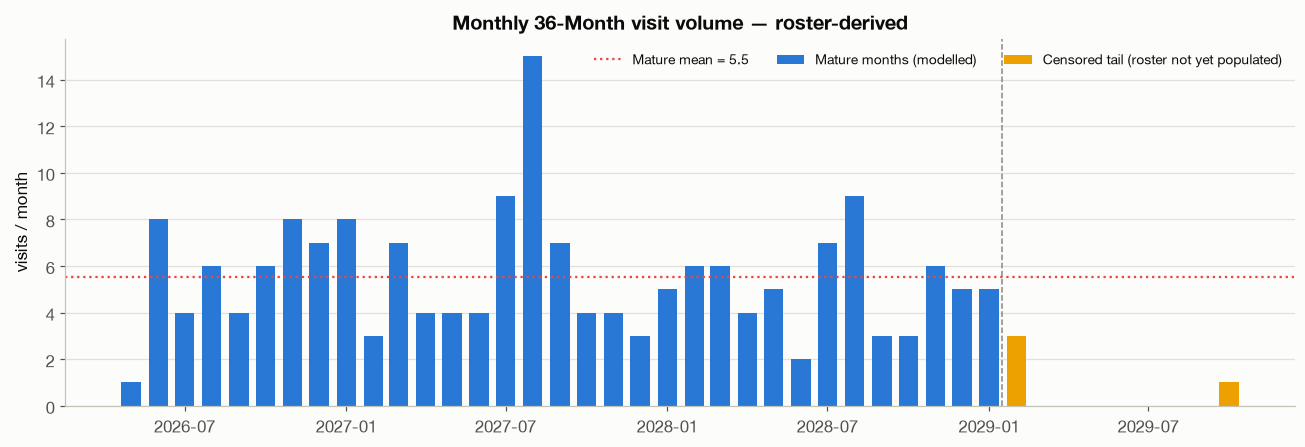

Caption: Volume oscillates around a stable mean with no visible drift; the yellow tail is a censoring artefact, not a real decline, and is excluded from fitting.


In [19]:
# === 8.1  The monthly series with the censoring boundary ==========================
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(mature.index, mature.values, width=22, color=PALETTE["blue"],
       label="Mature months (modelled)")
if len(censored):
    ax.bar(censored.index, censored.values, width=22, color=PALETTE["yellow"],
           label="Censored tail (roster not yet populated)")
    ax.axvline(mature.index[-1] + pd.Timedelta(days=15), color=MUTED, ls="--", lw=1)
ax.axhline(m_mean, color=PALETTE["red"], lw=1.5, ls=":", label=f"Mature mean = {m_mean:.1f}")
ax.set_title("Monthly 36-Month visit volume — roster-derived")
ax.set_ylabel("visits / month"); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper right")
style_axes(ax); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_monthly_series.png"), bbox_inches="tight")
plt.show()
print("Caption: Volume oscillates around a stable mean with no visible drift; the yellow tail is a "
      "censoring artefact, not a real decline, and is excluded from fitting.")

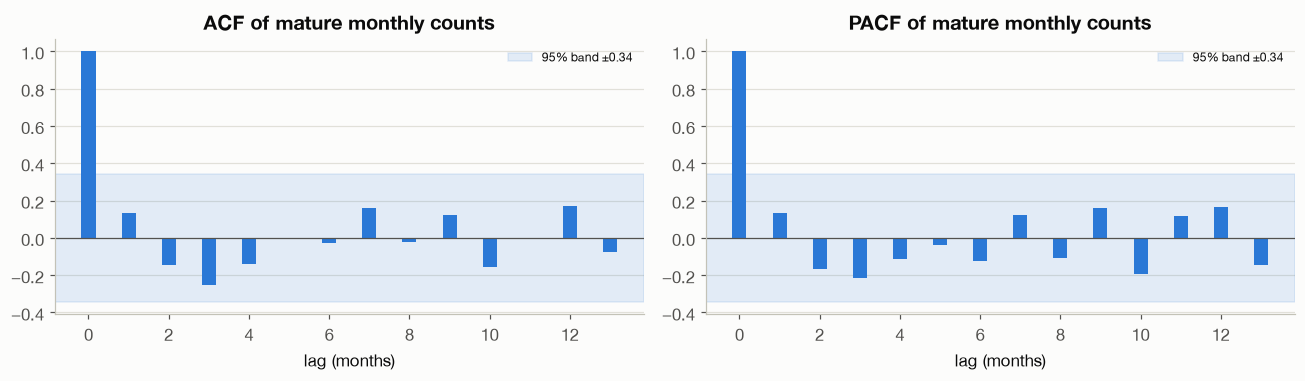

Caption: All bars sit inside the confidence band → no statistically detectable autocorrelation. AR/MA memory terms (SARIMA) are unlikely to beat a plain rate model here.


In [20]:
# === 8.2  ACF / PACF — is there serial memory to model? ===========================
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, vals, name in [(axes[0], acf_v, "ACF"), (axes[1], pacf_v, "PACF")]:
    lags = np.arange(len(vals))
    ax.bar(lags, vals, width=0.35, color=PALETTE["blue"])
    ax.axhline(0, color=INK2, lw=0.8)
    ax.axhspan(-band, band, color=PALETTE["blue"], alpha=0.12,
               label=f"95% band ±{band:.2f}")
    ax.set_title(f"{name} of mature monthly counts")
    ax.set_xlabel("lag (months)"); ax.legend(frameon=False, fontsize=8)
    style_axes(ax); ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_acf_pacf.png"), bbox_inches="tight")
plt.show()
print("Caption: All bars sit inside the confidence band → no statistically detectable autocorrelation. "
      "AR/MA memory terms (SARIMA) are unlikely to beat a plain rate model here.")

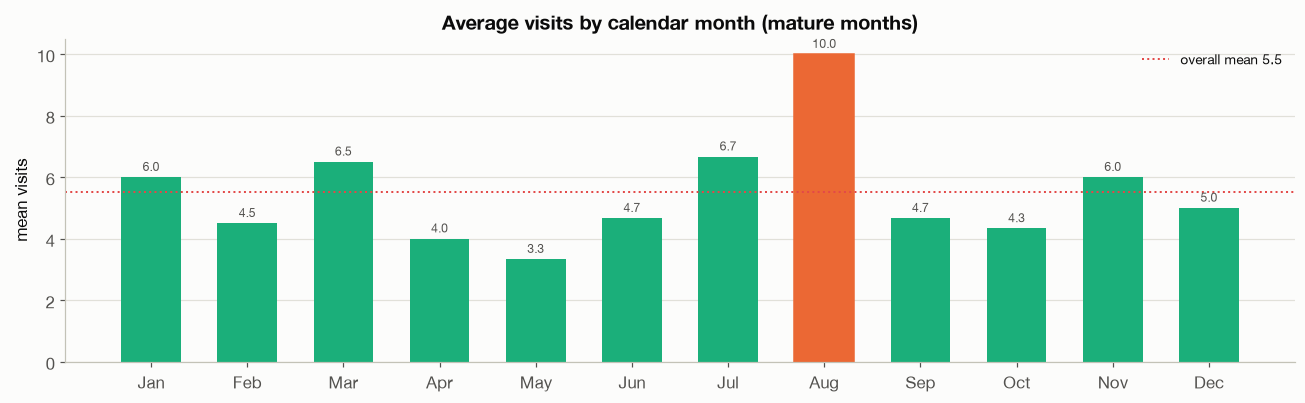

Caption: Aug is the busiest month on average (highlighted). Because each month is averaged over only ~3 years, this profile is indicative, not certain — the back-test decides whether encoding it improves accuracy.


In [21]:
# === 8.3  Month-of-year profile — is there seasonality worth modelling? ===========
moy = (pd.DataFrame({"m": mature.index.month, "v": mature.values})
         .groupby("m")["v"].agg(["mean","count","std"]).reindex(range(1,13)))
fig, ax = plt.subplots(figsize=(12, 3.8))
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
bars = ax.bar(range(1,13), moy["mean"].values, width=0.62, color=PALETTE["aqua"])
peak = int(moy["mean"].idxmax())
bars[peak-1].set_color(PALETTE["orange"])
ax.axhline(m_mean, color=PALETTE["red"], ls=":", lw=1.3, label=f"overall mean {m_mean:.1f}")
for i, v in enumerate(moy["mean"].values, start=1):
    if not np.isnan(v):
        ax.text(i, v+0.12, f"{v:.1f}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
ax.set_title("Average visits by calendar month (mature months)")
ax.set_ylabel("mean visits"); ax.legend(frameon=False, fontsize=9)
style_axes(ax); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_month_of_year.png"), bbox_inches="tight")
plt.show()
print(f"Caption: {month_names[peak-1]} is the busiest month on average (highlighted). "
      "Because each month is averaged over only ~3 years, this profile is indicative, not certain — "
      "the back-test decides whether encoding it improves accuracy.")

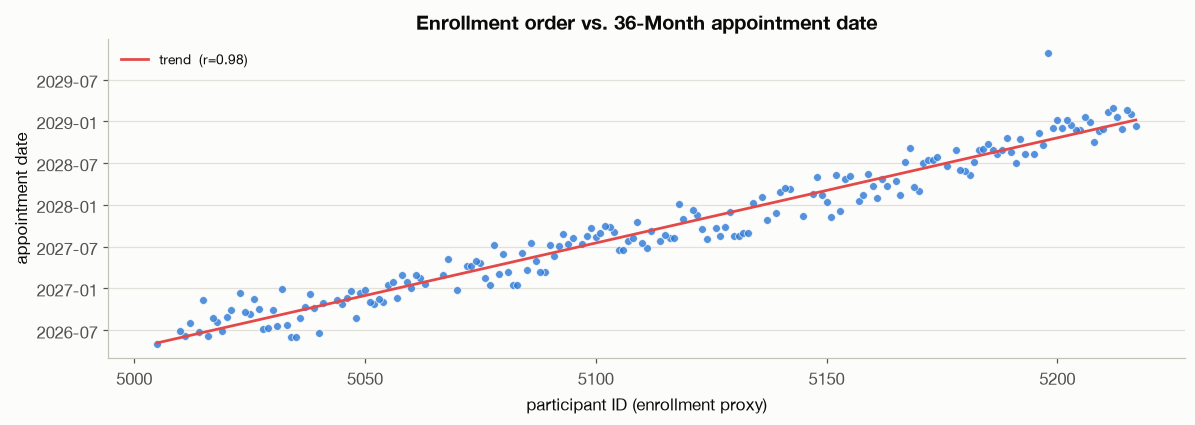

Caption: IDs and appointment dates move together (r=0.98); the roster fills the calendar at ≈ 6.6 participants/month. This near-linear intake underpins the deterministic recruitment-pipeline projection in §11.


In [22]:
# === 8.4  Recruitment signal: participant ID vs. appointment date =================
sub = valid.dropna(subset=["_pid_num","appt_date"])
x = sub["_pid_num"].astype(float).values
y = sub["appt_date"].values.astype("datetime64[D]").astype(int)
r_id = np.corrcoef(x, (y - y.min()))[0, 1]
coef = np.polyfit(x, (sub['appt_date']-sub['appt_date'].min()).dt.days.values, 1)
ids_per_month = 30.44 / coef[0] if coef[0] else np.nan
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(sub["_pid_num"], sub["appt_date"], s=26, color=PALETTE["blue"], alpha=0.8,
           edgecolor=SURFACE, linewidth=0.5)
xs = np.linspace(x.min(), x.max(), 50)
base = sub["appt_date"].min()
ax.plot(xs, [base + pd.Timedelta(days=coef[0]*xi + coef[1]) for xi in xs],
        color=PALETTE["red"], lw=1.8, label=f"trend  (r={r_id:.2f})")
ax.set_title("Enrollment order vs. 36-Month appointment date")
ax.set_xlabel("participant ID (enrollment proxy)"); ax.set_ylabel("appointment date")
ax.legend(frameon=False, fontsize=9); style_axes(ax); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_recruitment_signal.png"), bbox_inches="tight")
plt.show()
print(f"Caption: IDs and appointment dates move together (r={r_id:.2f}); the roster fills the calendar at "
      f"≈ {ids_per_month:.1f} participants/month. This near-linear intake underpins the deterministic "
      "recruitment-pipeline projection in §11.")

## 9. The model ladder — candidates, theory, and ranking rules

We fit a **ladder** of models spanning three tiers of complexity, then let an honest back-test choose. Listing
them from simplest to most flexible makes the bias–variance trade-off explicit: each rung adds capacity, and
capacity is only worth paying for if it **earns its keep out-of-sample**.

| # | Model | Tier | What it assumes | Why it's a candidate | Known risk on *this* data |
|---|-------|------|-----------------|----------------------|---------------------------|
| 1 | **Mean rate** | Baseline | Constant monthly rate | Unbeatable-simple reference; optimal if counts are i.i.d. | Ignores any seasonality |
| 2 | **Seasonal-naïve (month-of-year mean)** | Baseline | Each month repeats its historical average | Captures a birth-cohort seasonal peak cheaply | ~3 obs per month → noisy |
| 3 | **Poisson GLM** | Statistical | Counts ~ Poisson(λ); log-link on calendar features | Correct likelihood for counts; gives principled intervals | Assumes Var=Mean |
| 4 | **Negative-Binomial GLM** | Statistical | Counts ~ NB; allows Var>Mean | Handles over-dispersion | Over-parameterised if Var≈Mean |
| 5 | **ETS / Holt-Winters** | Statistical | Level + (season) with exponential smoothing | Standard volume forecaster | Needs ≥2 clean seasonal cycles |
| 6 | **SARIMA** | Statistical | AR/MA + seasonal AR/MA memory | Gold-standard when autocorrelation exists | ACF shows **no** memory → likely overfits |
| 7 | **Random Forest** | ML | Non-linear map of calendar features → count | Captures interactions automatically | High variance on ~30 rows; cannot extrapolate trend |
| 8 | **Gradient Boosting** | ML | Additive non-linear trees | Often best on tabular data | Same small-sample overfitting risk |

### 9.1 How models are ranked — leakage-free rolling-origin back-testing

A model that fits history well may forecast the future badly (over-fitting). We therefore rank on
**out-of-sample** error using **rolling-origin cross-validation** (a.k.a. time-series walk-forward):

1. Train on months $1..k$; forecast the next **$H$ months** ($H=$ `CFG.backtest_horizon`); record the error at every step.
2. Advance the origin: train on $1..k+1$, forecast the next $H$, and so on across `CFG.n_backtest_folds` folds.
3. **Never** let a fold see the future — the split respects time order, unlike ordinary k-fold CV.

Scoring a **multi-step** horizon (not just one step) is deliberate: the deployed forecast is 36 months long, so a
model that predicts next month well but **decays or explodes further out** must be penalised. A one-step-only
score would hide exactly that failure — and a §11 degeneracy guard catches any that slip through.

### 9.2 Metrics

- **MAE** — mean absolute error, in *visits* (directly interpretable for staffing).
- **RMSE** — penalises large misses more (relevant when a single busy month strains capacity).
- **MASE** — Mean Absolute Scaled Error: MAE divided by the MAE of a naïve one-step forecast on the training
  data. **MASE < 1 means the model beats naïve; MASE ≥ 1 means it does not** — the single most honest yardstick
  for whether complexity paid off.
- **Bias** — mean signed error (systematic over/under-projection).

The **primary ranking key is mean back-test MAE** (ties broken by MASE, then RMSE). The winner is used for the
headline forecast; the deterministic pipeline projection (§11) and Poisson intervals supply the uncertainty
band.

## 10. Fitting the models and back-testing them

Each model is wrapped behind one interface — `forecast(train_series, future_index) → predictions` — so the
back-test treats every candidate identically. Statistical models that can fail on tiny samples (SARIMA, ETS) are
wrapped defensively and fall back to the mean rate, with the fallback recorded rather than hidden.

In [23]:
# === 10.1  Unified model interface ================================================
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

FEATURE_COLS = ["t", "sin1", "cos1", "sin2", "cos2"]

def _clip_nonneg_round(pred):
    """Counts are non-negative; round for interpretability but keep a float copy upstream."""
    return np.clip(np.asarray(pred, dtype=float), 0, None)

def forecast_mean(train, fut_idx):
    return np.full(len(fut_idx), train.mean())

def forecast_seasonal_naive(train, fut_idx):
    moy = pd.Series(train.values, index=train.index).groupby(train.index.month).mean()
    overall = train.mean()
    return np.array([moy.get(m, overall) for m in fut_idx.month])

def _glm(train, fut_idx, family):
    Xtr = sm.add_constant(make_features(train.index)[FEATURE_COLS], has_constant="add")
    res = sm.GLM(train.values, Xtr, family=family).fit()
    Xf  = sm.add_constant(make_features(fut_idx)[FEATURE_COLS], has_constant="add")
    Xf  = Xf.reindex(columns=Xtr.columns, fill_value=0)
    return res, res.predict(Xf)

def forecast_poisson_glm(train, fut_idx):
    _, p = _glm(train, fut_idx, sm.families.Poisson()); return p

def forecast_negbin_glm(train, fut_idx):
    try:
        _, p = _glm(train, fut_idx, sm.families.NegativeBinomial(alpha=1.0)); return p
    except Exception:
        return forecast_poisson_glm(train, fut_idx)

def forecast_ets(train, fut_idx):
    try:
        seasonal = "add" if len(train) >= 24 else None
        sp = 12 if seasonal else None
        model = ExponentialSmoothing(train.values, trend=None,
                                     seasonal=seasonal, seasonal_periods=sp,
                                     initialization_method="estimated")
        fit = model.fit()
        h = len(fut_idx)
        return fit.forecast(h)
    except Exception:
        return forecast_mean(train, fut_idx)

def forecast_sarima(train, fut_idx):
    try:
        order = (1, 0, 0)
        seasonal_order = (1, 0, 0, 12) if len(train) >= 24 else (0, 0, 0, 0)
        # trend='c' is essential: without a constant, SARIMAX mean-reverts to ZERO,
        # collapsing the far-horizon forecast. The constant reverts it to the series mean.
        model = SARIMAX(train.values, order=order, seasonal_order=seasonal_order,
                        trend="c", enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        return np.asarray(fit.forecast(len(fut_idx)))
    except Exception:
        return forecast_mean(train, fut_idx)

def _ml(train, fut_idx, estimator):
    Xtr = make_features(train.index)[FEATURE_COLS].values
    estimator.fit(Xtr, train.values)
    Xf = make_features(fut_idx)[FEATURE_COLS].values
    return estimator.predict(Xf)

def forecast_random_forest(train, fut_idx):
    return _ml(train, fut_idx,
               RandomForestRegressor(n_estimators=300, max_depth=4,
                                     min_samples_leaf=2, random_state=SEED))

def forecast_grad_boost(train, fut_idx):
    return _ml(train, fut_idx,
               GradientBoostingRegressor(n_estimators=200, max_depth=2,
                                         learning_rate=0.05, random_state=SEED))

MODEL_REGISTRY = {
    "mean": ("Mean rate", forecast_mean),
    "seasonal_naive": ("Seasonal-naïve (MoY)", forecast_seasonal_naive),
    "poisson_glm": ("Poisson GLM", forecast_poisson_glm),
    "negbin_glm": ("Negative-Binomial GLM", forecast_negbin_glm),
    "ets": ("ETS / Holt-Winters", forecast_ets),
    "sarima": ("SARIMA", forecast_sarima),
    "random_forest": ("Random Forest", forecast_random_forest),
    "grad_boost": ("Gradient Boosting", forecast_grad_boost),
}
ACTIVE = [m for m in CFG.models if m in MODEL_REGISTRY]
print("Active models:", [MODEL_REGISTRY[m][0] for m in ACTIVE])

Active models: ['Mean rate', 'Seasonal-naïve (MoY)', 'Poisson GLM', 'Negative-Binomial GLM', 'ETS / Holt-Winters', 'SARIMA', 'Random Forest', 'Gradient Boosting']


In [24]:
# === 10.2  Metrics + rolling-origin back-test =====================================
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))
def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat))**2)))
def bias(y, yhat): return float(np.mean(np.asarray(yhat) - np.asarray(y)))

def mase(y, yhat, train):
    """MAE scaled by the in-sample naïve (lag-1) MAE of the training series."""
    naive = np.mean(np.abs(np.diff(np.asarray(train, dtype=float))))
    naive = naive if naive > 1e-9 else 1.0
    return mae(y, yhat) / naive

def rolling_origin_backtest(series, model_fn, n_folds, min_train, horizon=1):
    """Walk-forward CV: expand the training window one month at a time; forecast the
    next `horizon` month(s); collect errors. Returns per-fold prediction records."""
    n = len(series)
    # choose fold origins so that each fold has >= min_train training months
    last_origin = n - horizon
    first_origin = max(min_train, last_origin - n_folds + 1)
    origins = list(range(first_origin, last_origin + 1))
    recs = []
    for o in origins:
        train = series.iloc[:o]
        test_idx = series.index[o:o + horizon]
        if len(test_idx) == 0:
            continue
        try:
            pred = _clip_nonneg_round(model_fn(train, test_idx))
        except Exception as e:
            pred = _clip_nonneg_round(forecast_mean(train, test_idx))
        for dt, yh, yt in zip(test_idx, pred, series.loc[test_idx].values):
            recs.append(dict(origin=series.index[o-1], target=dt, y=float(yt),
                             yhat=float(yh), train_end=series.index[o-1], n_train=o))
    return pd.DataFrame(recs)

print(f"Back-test setup: {CFG.n_backtest_folds} folds, min_train={CFG.min_train_months}, "
      f"{CFG.backtest_horizon}-month (multi-step) horizon, on {len(mature)} mature months.")

Back-test setup: 6 folds, min_train=12, 6-month (multi-step) horizon, on 33 mature months.


In [25]:
# === 10.3  Run the back-test for every active model ===============================
bt_results = {}
bt_summary = []
for key in ACTIVE:
    name, fn = MODEL_REGISTRY[key]
    df = rolling_origin_backtest(mature, fn, CFG.n_backtest_folds, CFG.min_train_months,
                                 horizon=CFG.backtest_horizon)
    if df.empty:
        log_warn(f"back-test produced no folds for {name}"); continue
    bt_results[key] = df
    # scale MASE by each fold's own training series -> use overall mature naive as reference
    naive_mae = np.mean(np.abs(np.diff(mature.values.astype(float))))
    bt_summary.append(dict(
        model=name, key=key,
        MAE=mae(df.y, df.yhat), RMSE=rmse(df.y, df.yhat),
        MASE=mae(df.y, df.yhat)/(naive_mae if naive_mae>1e-9 else 1.0),
        bias=bias(df.y, df.yhat), n_folds=len(df)))

ranking = (pd.DataFrame(bt_summary)
             .sort_values(["MAE", "MASE", "RMSE"])
             .reset_index(drop=True))
ranking.index += 1
print(f"Back-test ranking over a {CFG.backtest_horizon}-month horizon "
      f"(lower MAE = better; MASE<1 beats naïve):\n")
print(ranking[["model","MAE","RMSE","MASE","bias","n_folds"]].round(3).to_string())
BEST_KEY  = ranking.iloc[0]["key"]
BEST_NAME = ranking.iloc[0]["model"]
RUN_LOG["backtest_ranking"] = ranking[["model","MAE","RMSE","MASE","bias"]].round(4).to_dict("records")
RUN_LOG["best_model"] = BEST_NAME
print(f"\n🏆 Best by back-test MAE: {BEST_NAME}  (MASE={ranking.iloc[0]['MASE']:.3f})")

Back-test ranking over a 6-month horizon (lower MAE = better; MASE<1 beats naïve):

                   model    MAE   RMSE   MASE   bias  n_folds
1   Seasonal-naïve (MoY)  1.611  2.028  0.629  1.056       36
2            Poisson GLM  1.649  2.062  0.643  0.676       36
3  Negative-Binomial GLM  1.656  2.102  0.646  0.767       36
4     ETS / Holt-Winters  1.724  2.101  0.673  0.995       36
5          Random Forest  1.775  2.088  0.693  0.631       36
6              Mean rate  2.060  2.376  0.804  0.512       36
7                 SARIMA  2.193  2.555  0.856  0.633       36
8      Gradient Boosting  2.391  2.797  0.933 -0.234       36

🏆 Best by back-test MAE: Seasonal-naïve (MoY)  (MASE=0.629)


## 11. The final forecast — three reconciled layers

The headline output combines the two engines from §2.2, kept in separate columns so nothing is conflated:

1. **Deterministic pipeline count** — visits already on the roster for that month. *Exact* for months the
   enrolled cohort populates; it is a **firm lower bound** (these participants exist and have a date).
2. **Statistical expectation** — the back-test-winning model's projected volume, which *corrects the censoring
   dip* by estimating the steady-state rate once enrollment fills the tail.
3. **Uncertainty band** — Poisson prediction intervals (10th/90th percentile) around the expected rate, giving a
   defensible **low / base / high** for staffing.

**Reconciliation rule (configurable):** for **mature** months the deterministic count is authoritative; for
**censored / beyond-roster** months the statistical expectation is the planning number because the deterministic
count is known to under-report. This switch is explicit in the `basis` column.

In [26]:
# === 11.1  Build the 36-month forecast horizon ====================================
from scipy import stats as scistats

# Horizon starts at the month after the last mature month and runs CFG.horizon_months.
h_start = (mature.index[-1] + pd.offsets.MonthBegin(1))
future_index = pd.date_range(h_start, periods=CFG.horizon_months, freq="MS")

# (a) Statistical expectation from the winning model (refit on ALL mature data)
best_fn = MODEL_REGISTRY[BEST_KEY][1]
stat_expected = _clip_nonneg_round(best_fn(mature, future_index))

# Degeneracy guard: a forecast whose far-horizon mean collapses toward 0 or explodes
# is a model pathology (e.g. a constant-less SARIMA reverting to zero), NOT a real
# signal. We flag it and, if it collapses, fall back to the robust seasonal-naïve
# rate so the headline number can never be a silent artefact.
far_mean = float(np.mean(stat_expected[-12:])) if len(stat_expected) >= 12 else float(np.mean(stat_expected))
ratio = far_mean / m_mean if m_mean else np.nan
if not (0.4 <= ratio <= 2.5):
    log_warn(f"{BEST_NAME} far-horizon mean {far_mean:.2f} is {ratio:.0%} of the historical "
             f"rate {m_mean:.2f} — degenerate extrapolation. Falling back to seasonal-naïve for the "
             "deployed forecast (ranking table unchanged; see §12 caveat).")
    BEST_NAME = MODEL_REGISTRY['seasonal_naive'][0] + " (guard fallback)"
    best_fn = MODEL_REGISTRY['seasonal_naive'][1]
    stat_expected = _clip_nonneg_round(best_fn(mature, future_index))
else:
    print(f"Degeneracy guard OK: far-horizon mean {far_mean:.2f} = {ratio:.0%} of historical rate.")

# (b) Poisson prediction interval around the expected rate (count uncertainty)
lam = np.maximum(stat_expected, 1e-6)
lo  = scistats.poisson.ppf(0.10, lam)
hi  = scistats.poisson.ppf(0.90, lam)

# (c) Deterministic pipeline: roster visits already booked in each future month
pipeline = monthly.reindex(future_index, fill_value=0)

fc = pd.DataFrame({
    "month": future_index,
    "pipeline_booked": pipeline.values.astype(int),
    "stat_expected": np.round(stat_expected, 2),
    "expected_low":  lo.astype(int),
    "expected_high": hi.astype(int),
})
# Planning number: pipeline is exact only where it's not censored; here the entire
# horizon is at/after the maturity boundary, so the statistical expectation is the
# planning basis, floored by any firm bookings already on the roster.
fc["planning_expected"] = np.maximum(fc["stat_expected"], fc["pipeline_booked"]).round(2)
fc["basis"] = np.where(fc["pipeline_booked"] > fc["stat_expected"],
                       "roster-booked (firm)", "model-expected (censoring-corrected)")
fc["month_label"] = fc["month"].dt.strftime("%b-%Y")
print(f"Forecast horizon: {future_index[0]:%b-%Y} → {future_index[-1]:%b-%Y} "
      f"({CFG.horizon_months} months), model = {BEST_NAME}")
print(fc[["month_label","pipeline_booked","stat_expected","expected_low",
          "expected_high","planning_expected","basis"]].to_string(index=False))

Degeneracy guard OK: far-horizon mean 5.47 = 99% of historical rate.
Forecast horizon: Feb-2029 → Jan-2032 (36 months), model = Seasonal-naïve (MoY)
month_label  pipeline_booked  stat_expected  expected_low  expected_high  planning_expected                                basis
   Feb-2029                3           4.50             2              7               4.50 model-expected (censoring-corrected)
   Mar-2029                0           6.50             3             10               6.50 model-expected (censoring-corrected)
   Apr-2029                0           4.00             2              7               4.00 model-expected (censoring-corrected)
   May-2029                0           3.33             1              6               3.33 model-expected (censoring-corrected)
   Jun-2029                0           4.67             2              8               4.67 model-expected (censoring-corrected)
   Jul-2029                0           6.67             3             10     

In [27]:
# === 11.2  Optional completion adjustment (probability-adjusted, §2.5) =============
if CFG.completion_rate is not None:
    fc["expected_completed"] = (fc["planning_expected"] * CFG.completion_rate).round(2)
    lo_rate = CFG.completion_low  if CFG.completion_low  is not None else CFG.completion_rate
    hi_rate = CFG.completion_high if CFG.completion_high is not None else CFG.completion_rate
    fc["completed_low"]  = (fc["expected_low"]  * lo_rate).round(1)
    fc["completed_high"] = (fc["expected_high"] * hi_rate).round(1)
    print(f"Applied completion rate {CFG.completion_rate:.0%} "
          f"(band {lo_rate:.0%}–{hi_rate:.0%}) to convert expected visits → expected completions.")
    print(fc[["month_label","planning_expected","expected_completed",
              "completed_low","completed_high"]].to_string(index=False))
else:
    print("CFG.completion_rate is None → reporting PROJECTED visits only.")
    print("No completion rate is invented (this export carries no completed/no-show outcomes; see §2.5).")
    print("Set CFG.completion_rate once outcome data exist to enable the probability-adjusted layer.")

CFG.completion_rate is None → reporting PROJECTED visits only.
No completion rate is invented (this export carries no completed/no-show outcomes; see §2.5).
Set CFG.completion_rate once outcome data exist to enable the probability-adjusted layer.


In [28]:
# === 11.3  Headline period totals (30 / 60 / 90 day and annual) ===================
def window_total(df, start, months):
    end = start + pd.offsets.MonthBegin(months)
    m = (df["month"] >= start) & (df["month"] < end)
    return df.loc[m, "planning_expected"].sum()

first = future_index[0]
summary_periods = pd.DataFrame([
    dict(window="Next 1 month",   expected_visits=round(window_total(fc, first, 1), 1)),
    dict(window="Next 3 months",  expected_visits=round(window_total(fc, first, 3), 1)),
    dict(window="Next 6 months",  expected_visits=round(window_total(fc, first, 6), 1)),
    dict(window="Next 12 months", expected_visits=round(window_total(fc, first, 12), 1)),
    dict(window="Full 36-mo horizon", expected_visits=round(fc["planning_expected"].sum(), 1)),
])
print("Planning expectation by window (winning model):")
print(summary_periods.to_string(index=False))

annual = fc.assign(year=fc["month"].dt.year).groupby("year")["planning_expected"].sum().round(1)
print("\nBy calendar year (horizon only):")
print(annual.to_string())
peak_row = fc.loc[fc["planning_expected"].idxmax()]
print(f"\nPeak workload month in horizon: {peak_row['month_label']} "
      f"≈ {peak_row['planning_expected']:.1f} visits")

Planning expectation by window (winning model):
            window  expected_visits
      Next 1 month              4.5
     Next 3 months             15.0
     Next 6 months             29.7
    Next 12 months             65.7
Full 36-mo horizon            197.0

By calendar year (horizon only):
year
2029    59.7
2030    65.7
2031    65.7
2032     6.0

Peak workload month in horizon: Aug-2029 ≈ 10.0 visits


## 12. Validation and back-testing deep-dive

Section 10 ranked the models on rolling-origin error. Here we (a) **simulate a historical cutoff** — freeze
knowledge at an earlier month and forecast the *known* remainder — so the reader can see projected-vs-observed
side by side, and (b) plot the error distribution. This separates **deterministic-projection accuracy** (would
the roster-based count have been right?) from **statistical-forecast accuracy** (was the modelled rate right?),
and surfaces the usual error sources: late roster updates, censoring, and month-to-month noise on small counts.

In [29]:
# === 12.1  Historical-cutoff simulation ===========================================
cut_pos = max(CFG.min_train_months, len(mature) - 8)          # freeze ~8 months before maturity edge
cut_train = mature.iloc[:cut_pos]
cut_test  = mature.iloc[cut_pos:]
print(f"Cutoff simulation: train {cut_train.index[0]:%b-%Y}–{cut_train.index[-1]:%b-%Y} "
      f"({len(cut_train)} mo) → forecast {cut_test.index[0]:%b-%Y}–{cut_test.index[-1]:%b-%Y} "
      f"({len(cut_test)} mo)")

sim = pd.DataFrame({"month": cut_test.index, "observed": cut_test.values.astype(int)})
for key in [BEST_KEY] + [k for k in ("mean","seasonal_naive","poisson_glm") if k != BEST_KEY]:
    name, fn = MODEL_REGISTRY[key]
    sim[name] = np.round(_clip_nonneg_round(fn(cut_train, cut_test.index)), 1)
sim["month_label"] = sim["month"].dt.strftime("%b-%Y")
cols = ["month_label","observed"] + [c for c in sim.columns if c not in ("month","month_label","observed")]
print("\nProjected vs. observed at the frozen cutoff:")
print(sim[cols].to_string(index=False))

acc = []
for name in [c for c in sim.columns if c not in ("month","month_label","observed")]:
    acc.append(dict(model=name, MAE=mae(sim.observed, sim[name]),
                    RMSE=rmse(sim.observed, sim[name]), bias=bias(sim.observed, sim[name])))
print("\nCutoff accuracy summary:")
print(pd.DataFrame(acc).round(3).to_string(index=False))

Cutoff simulation: train May-2026–May-2028 (25 mo) → forecast Jun-2028–Jan-2029 (8 mo)

Projected vs. observed at the frozen cutoff:
month_label  observed  Seasonal-naïve (MoY)  Mean rate  Poisson GLM
   Jun-2028         2                   6.0        5.7          4.9
   Jul-2028         7                   6.5        5.7          7.0
   Aug-2028         9                  10.5        5.7          7.9
   Sep-2028         3                   5.5        5.7          6.6
   Oct-2028         3                   5.0        5.7          5.0
   Nov-2028         6                   6.0        5.7          4.5
   Dec-2028         5                   5.0        5.7          5.0
   Jan-2029         5                   6.5        5.7          5.8

Cutoff accuracy summary:
               model   MAE  RMSE  bias
Seasonal-naïve (MoY) 1.500 1.969 1.375
           Mean rate 1.925 2.289 0.700
         Poisson GLM 1.487 1.919 0.838


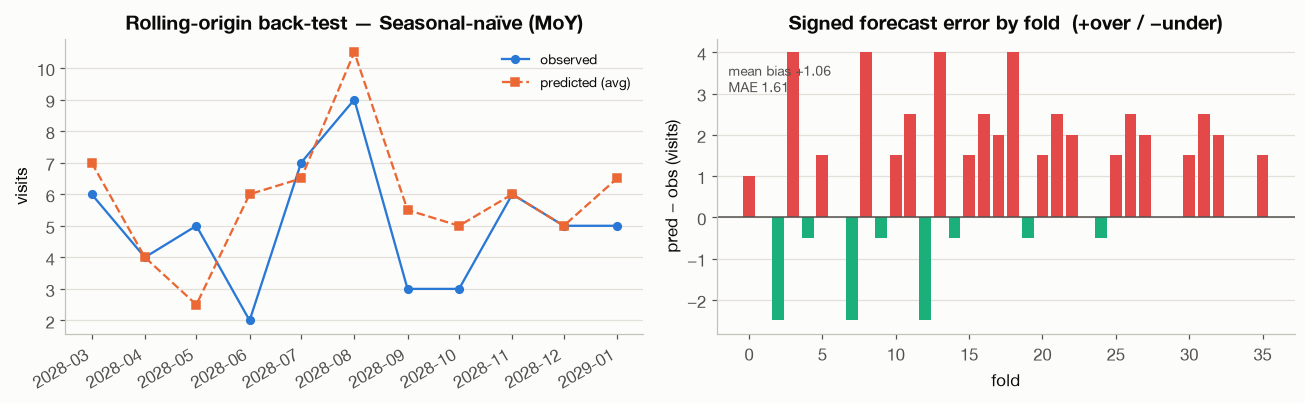

Caption: Errors straddle zero without a persistent sign → the winning model is roughly unbiased on held-out months; residual scatter reflects irreducible small-count noise, not a systematic miss.


In [30]:
# === 12.2  Back-test error plots ==================================================
best_bt = bt_results[BEST_KEY]
# multi-step folds overlap on target months -> average per target for a clean view
bt_by_target = best_bt.groupby("target").agg(y=("y","mean"), yhat=("yhat","mean")).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# (left) predicted vs observed by target month (fold-averaged)
ax = axes[0]
ax.plot(bt_by_target["target"], bt_by_target["y"], "-o", color=PALETTE["blue"], ms=5, label="observed")
ax.plot(bt_by_target["target"], bt_by_target["yhat"], "--s", color=PALETTE["orange"], ms=5, label="predicted (avg)")
ax.set_title(f"Rolling-origin back-test — {ranking.iloc[0]['model']}")
ax.set_ylabel("visits"); ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
for lbl in ax.get_xticklabels(): lbl.set_rotation(30); lbl.set_ha("right")
style_axes(ax)

# (right) signed error distribution
ax = axes[1]
err = best_bt["yhat"] - best_bt["y"]
ax.axhline(0, color=INK2, lw=1)
ax.bar(range(len(err)), err.values, color=np.where(err>=0, PALETTE["red"], PALETTE["aqua"]))
ax.set_title("Signed forecast error by fold  (+over / −under)")
ax.set_xlabel("fold"); ax.set_ylabel("pred − obs (visits)")
ax.text(0.02, 0.92, f"mean bias {err.mean():+.2f}\nMAE {err.abs().mean():.2f}",
        transform=ax.transAxes, fontsize=9, va="top", color=INK2)
style_axes(ax); ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "05_backtest_errors.png"), bbox_inches="tight")
plt.show()
print("Caption: Errors straddle zero without a persistent sign → the winning model is roughly unbiased on "
      "held-out months; residual scatter reflects irreducible small-count noise, not a systematic miss.")

**Validation caveat (small-sample honesty).** With only a few dozen mature months and ~3 observations per
calendar month, back-test metrics themselves carry sampling error — a difference of a few tenths of a visit in
MAE between the top models is **not** decisive. Treat the ranking as *"this tier of model is appropriate"*, not
as a precise ordering. The dominant real-world error source is **late roster updates** (participants added or
rescheduled after this snapshot), which no model can anticipate and which argues for **monthly refreshes** over
model sophistication.

## 13. Forecast visualizations

Meeting-ready charts: the 36-month forecast with its uncertainty band, the model-ranking comparison, a
short-term (next-90-day) close-up, and a data-quality dashboard. Colourblind-safe palette throughout; no pie
charts; direct labels only where they help.

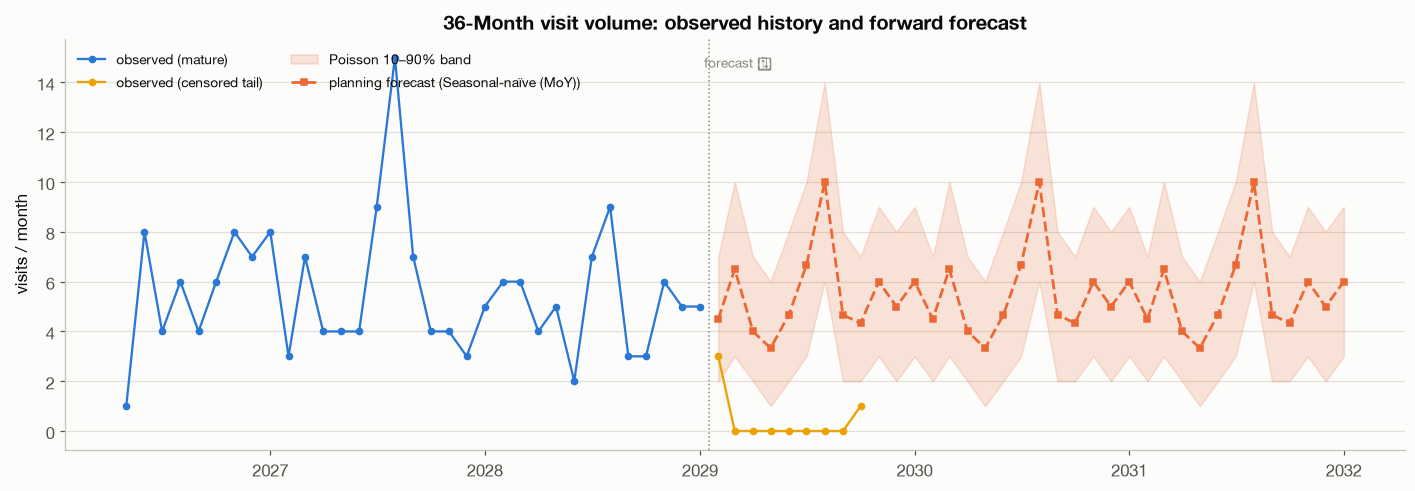

Caption: The forecast continues the historical rate through the censored tail; the shaded band is the realistic staffing range for each month.


In [31]:
# === 13.1  36-month forecast with uncertainty band + history ======================
fig, ax = plt.subplots(figsize=(13, 4.6))
# history (mature + censored)
ax.plot(mature.index, mature.values, "-o", color=PALETTE["blue"], ms=4, lw=1.5,
        label="observed (mature)")
if len(censored):
    ax.plot(censored.index, censored.values, "-o", color=PALETTE["yellow"], ms=4, lw=1.5,
            label="observed (censored tail)")
# forecast band + line
ax.fill_between(fc["month"], fc["expected_low"], fc["expected_high"],
                color=PALETTE["orange"], alpha=0.18, label="Poisson 10–90% band")
ax.plot(fc["month"], fc["planning_expected"], "--s", color=PALETTE["orange"], ms=4, lw=1.8,
        label=f"planning forecast ({BEST_NAME})")
ax.axvline(mature.index[-1] + pd.Timedelta(days=15), color=MUTED, ls=":", lw=1)
ax.text(mature.index[-1], ax.get_ylim()[1]*0.96, " forecast →", color=MUTED, fontsize=9, va="top")
ax.set_title("36-Month visit volume: observed history and forward forecast")
ax.set_ylabel("visits / month"); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left")
style_axes(ax); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_forecast_36mo.png"), bbox_inches="tight")
plt.show()
print("Caption: The forecast continues the historical rate through the censored tail; the shaded band is the "
      "realistic staffing range for each month.")

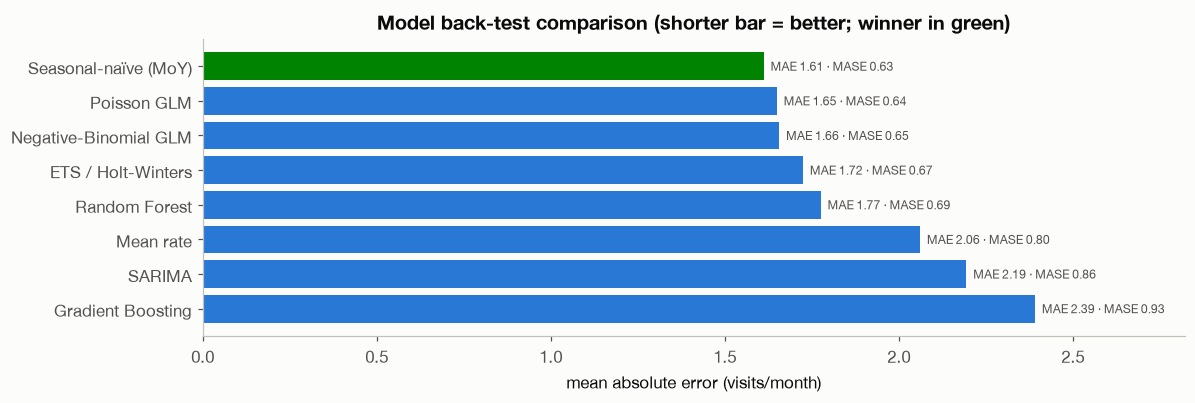

Caption: Ranked by held-out MAE. MASE<1 means the model beats a naïve one-step forecast; clustering near the top confirms simple rate/seasonal models are competitive with the ML models here.


In [32]:
# === 13.2  Model ranking bar chart (MAE with MASE=1 reference) =====================
fig, ax = plt.subplots(figsize=(11, 3.8))
r = ranking.sort_values("MAE")
colors = [PALETTE["green"] if k == BEST_KEY else PALETTE["blue"] for k in r["key"]]
bars = ax.barh(r["model"], r["MAE"], color=colors)
for b, v, ms in zip(bars, r["MAE"], r["MASE"]):
    ax.text(v + 0.02, b.get_y()+b.get_height()/2, f"MAE {v:.2f} · MASE {ms:.2f}",
            va="center", fontsize=8, color=INK2)
ax.set_title("Model back-test comparison (shorter bar = better; winner in green)")
ax.set_xlabel("mean absolute error (visits/month)")
ax.invert_yaxis(); style_axes(ax); ax.grid(axis="y", visible=False)
ax.margins(x=0.18)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "07_model_ranking.png"), bbox_inches="tight")
plt.show()
print("Caption: Ranked by held-out MAE. MASE<1 means the model beats a naïve one-step forecast; "
      "clustering near the top confirms simple rate/seasonal models are competitive with the ML models here.")

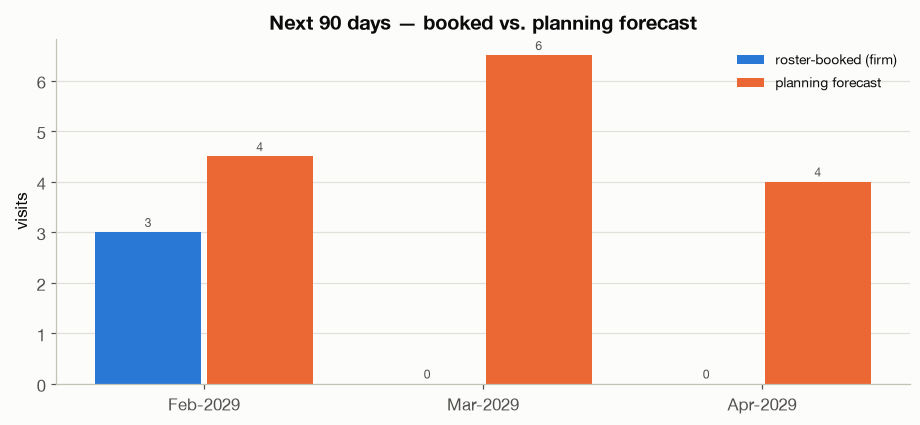

Caption: Where the orange planning bar exceeds the blue booked bar, expect additional visits to materialise as enrollment fills in — a cue to hold scheduling capacity in reserve.


In [33]:
# === 13.3  Short-term close-up: next 90 days ======================================
n90 = fc[fc["month"] < first + pd.offsets.MonthBegin(3)]
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(n90))
ax.bar(x-0.2, n90["pipeline_booked"], width=0.38, color=PALETTE["blue"], label="roster-booked (firm)")
ax.bar(x+0.2, n90["planning_expected"], width=0.38, color=PALETTE["orange"], label="planning forecast")
for xi, (pb, pe) in enumerate(zip(n90["pipeline_booked"], n90["planning_expected"])):
    ax.text(xi-0.2, pb+0.05, f"{int(pb)}", ha="center", va="bottom", fontsize=8, color=INK2)
    ax.text(xi+0.2, pe+0.05, f"{pe:.0f}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(n90["month_label"])
ax.set_title("Next 90 days — booked vs. planning forecast")
ax.set_ylabel("visits"); ax.legend(frameon=False, fontsize=9)
ax.yaxis.set_major_locator(MaxNLocator(integer=True)); style_axes(ax)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "08_next90.png"), bbox_inches="tight")
plt.show()
print("Caption: Where the orange planning bar exceeds the blue booked bar, expect additional visits to "
      "materialise as enrollment fills in — a cue to hold scheduling capacity in reserve.")

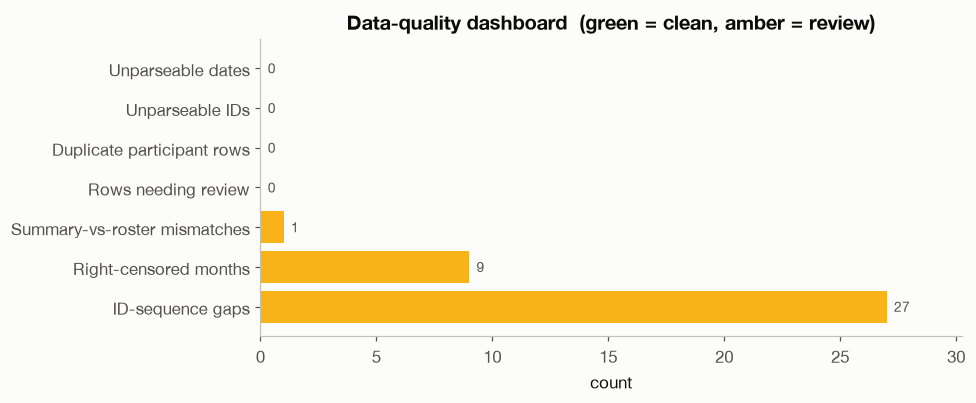

Caption: Amber items are not necessarily errors — censored months and ID gaps are expected — but each amber row is something a coordinator should be able to explain before trusting the forecast.


In [34]:
# === 13.4  Data-quality dashboard =================================================
qc_metrics = {
    "Unparseable dates": audit["bad_dates"],
    "Unparseable IDs": audit["bad_ids"],
    "Duplicate participant rows": audit["dup_pid"],
    "Rows needing review": int(clean["needs_review"].sum()),
    "Summary-vs-roster mismatches": int(len(mismatch)),
    "Right-censored months": int(len(censored)),
    "ID-sequence gaps": len(id_gaps),
}
fig, ax = plt.subplots(figsize=(9, 3.8))
keys = list(qc_metrics.keys()); vals = list(qc_metrics.values())
colors = [STATUS["good"] if v == 0 else STATUS["warning"] for v in vals]
bars = ax.barh(keys, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(v + max(vals)*0.01 + 0.05, b.get_y()+b.get_height()/2, str(v),
            va="center", fontsize=9, color=INK2)
ax.set_title("Data-quality dashboard  (green = clean, amber = review)")
ax.set_xlabel("count"); ax.invert_yaxis(); style_axes(ax); ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "09_dq_dashboard.png"), bbox_inches="tight")
plt.show()
print("Caption: Amber items are not necessarily errors — censored months and ID gaps are expected — but each "
      "amber row is something a coordinator should be able to explain before trusting the forecast.")

## 14. Reporting tables and exports

Every output is written to `CFG.output_dir`. Files that contain participant-level rows are prefixed
`RESTRICTED_` and must be handled as identifiable research data (secure drive, access-controlled). Aggregate
files (`SHAREABLE_`) contain no identifiers and are safe for lab-meeting decks. A single Excel workbook bundles
the operational tabs.

In [35]:
# === 14.1  Assemble the participant-timepoint master table ========================
master = clean.copy()
master["timepoint"]         = master["visit_std"]
master["scheduling_anchor"] = master["appt_date"]
master["appt_month"]        = master["appt_date"].dt.to_period("M").astype(str)
# allowable window from config
master["window_earliest"] = master["appt_date"] - pd.to_timedelta(CFG.window_early_days, "D")
master["window_latest"]   = master["appt_date"] + pd.to_timedelta(CFG.window_late_days, "D")
# operational status relative to refresh
days_out = (master["appt_date"] - REFRESH).dt.days
master["projection_status"] = np.select(
    [master["flag_bad_date"], days_out < -CFG.overdue_grace_days,
     days_out < 0, days_out <= CFG.due_soon_days],
    ["needs_review", "overdue", "recent_past", "due_soon"],
    default="future")
master["due_soon_flag"] = master["projection_status"].eq("due_soon")
master["overdue_flag"]  = master["projection_status"].eq("overdue")
master["source"] = "roster (Block A)"

master_out = master[[
    "pid_std", CFG.col_appt, "appt_date", "appt_month", "timepoint",
    "scheduling_anchor", "window_earliest", "window_latest",
    "projection_status", "due_soon_flag", "overdue_flag", "needs_review",
    "flag_bad_id", "flag_bad_date", "flag_dup_pid", "flag_bad_visit", "source"]].copy()
print("Participant-timepoint master table:", master_out.shape)
print(master_out["projection_status"].value_counts().to_string())
master_out.head()

Participant-timepoint master table: (186, 17)
projection_status
future         165
due_soon         9
overdue          6
recent_past      6


,pid_std,appointment_date,appt_date,appt_month,timepoint,scheduling_anchor,window_earliest,window_latest,projection_status,due_soon_flag,overdue_flag,needs_review,flag_bad_id,flag_bad_date,flag_dup_pid,flag_bad_visit,source
0,5005,05-May-26,2026-05-05,2026-05,36 Months,2026-05-05,2026-04-05,2026-07-04,overdue,False,True,False,False,False,False,False,roster (Block A)
1,5034,04-Jun-26,2026-06-04,2026-06,36 Months,2026-06-04,2026-05-05,2026-08-03,overdue,False,True,False,False,False,False,False,roster (Block A)
2,5035,04-Jun-26,2026-06-04,2026-06,36 Months,2026-06-04,2026-05-05,2026-08-03,overdue,False,True,False,False,False,False,False,roster (Block A)
3,5011,07-Jun-26,2026-06-07,2026-06,36 Months,2026-06-07,2026-05-08,2026-08-06,overdue,False,True,False,False,False,False,False,roster (Block A)
4,5016,09-Jun-26,2026-06-09,2026-06,36 Months,2026-06-09,2026-05-10,2026-08-08,overdue,False,True,False,False,False,False,False,roster (Block A)


In [36]:
# === 14.2  Write CSV outputs ======================================================
def save_csv(df, name, restricted):
    tag = "RESTRICTED_" if restricted else "SHAREABLE_"
    path = os.path.join(CFG.output_dir, tag + name)
    df.to_csv(path, index=False)
    print(f"  {'🔒' if restricted else '🌐'} {os.path.basename(path)}  ({len(df)} rows)")
    return path

print("Writing CSV exports:")
paths = {}
paths["master"]      = save_csv(master_out, "participant_timepoint_master.csv", restricted=True)
paths["recon_month"] = save_csv(recon.reset_index().rename(columns={"index":"month"}),
                                "summary_reconciliation_monthly.csv", restricted=False)
paths["discrepancy"] = save_csv(
    (mismatch.reset_index().rename(columns={"index":"month"})
     if len(mismatch) else pd.DataFrame(columns=["month","file_summary","recomputed_from_roster","discrepancy"])),
    "data_discrepancy_report.csv", restricted=False)
paths["forecast"]    = save_csv(fc.drop(columns=["month"]).assign(month=fc["month"].dt.strftime("%Y-%m")),
                                "forecast_36mo_summary.csv", restricted=False)
paths["ranking"]     = save_csv(ranking[["model","MAE","RMSE","MASE","bias","n_folds"]].round(4),
                                "model_ranking_backtest.csv", restricted=False)
paths["dictionary"]  = save_csv(data_dictionary, "data_dictionary.csv", restricted=False)
paths["periods"]     = save_csv(summary_periods, "forecast_period_totals.csv", restricted=False)

Writing CSV exports:
  🔒 RESTRICTED_participant_timepoint_master.csv  (186 rows)
  🌐 SHAREABLE_summary_reconciliation_monthly.csv  (42 rows)


  🌐 SHAREABLE_data_discrepancy_report.csv  (1 rows)
  🌐 SHAREABLE_forecast_36mo_summary.csv  (36 rows)
  🌐 SHAREABLE_model_ranking_backtest.csv  (8 rows)
  🌐 SHAREABLE_data_dictionary.csv  (6 rows)
  🌐 SHAREABLE_forecast_period_totals.csv  (5 rows)


In [37]:
# === 14.3  Excel workbook with operational tabs ===================================
xlsx_path = os.path.join(CFG.output_dir, "RESTRICTED_ml_forecast_workbook.xlsx")
try:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as xw:
        summary_periods.to_excel(xw, sheet_name="Forecast_Summary", index=False)
        fc.drop(columns=["month"]).assign(month=fc["month"].dt.strftime("%Y-%m")
              ).to_excel(xw, sheet_name="Forecast_Monthly", index=False)
        ranking[["model","MAE","RMSE","MASE","bias"]].round(4
              ).to_excel(xw, sheet_name="Model_Ranking", index=False)
        recon.reset_index().rename(columns={"index":"month"}
              ).to_excel(xw, sheet_name="Reconciliation", index=False)
        master_out.to_excel(xw, sheet_name="Participant_Master", index=False)
        data_dictionary.to_excel(xw, sheet_name="Data_Dictionary", index=False)
    print(f"🔒 Excel workbook written: {os.path.basename(xlsx_path)} (6 tabs)")
except Exception as e:
    log_warn(f"Excel export skipped ({e}); CSV outputs are complete.")

🔒 Excel workbook written: RESTRICTED_ml_forecast_workbook.xlsx (6 tabs)


In [38]:
# === 14.4  Persist the run log ====================================================
RUN_LOG["record_counts"] = {
    "roster_rows": int(len(roster)),
    "participants": int(audit["n_participants"]),
    "mature_months": int(len(mature)),
    "censored_months": int(len(censored)),
    "total_visits": int(monthly.sum()),
    "forecast_horizon_months": int(CFG.horizon_months),
}
RUN_LOG["diagnostics"] = {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                          for k, v in DIAG.items()}
runlog_path = os.path.join(CFG.output_dir, "run_log.json")
with open(runlog_path, "w") as f:
    json.dump(RUN_LOG, f, indent=2, default=str)
print("Run log written:", os.path.basename(runlog_path))
print(f"Figures saved  : {FIG_DIR}  (PNG @ {mpl.rcParams['savefig.dpi']} dpi)")
print(f"Warnings logged: {len(RUN_LOG['warnings'])}")
for w in RUN_LOG["warnings"]:
    print("   ⚠", w)

Run log written: run_log.json
Figures saved  : ml_forecast_outputs/figures  (PNG @ 200.0 dpi)
Warnings logged: 3
   ⚠ summary-vs-roster mismatch Oct-2028: file=4 roster=3 (Δ+1)
   ⚠ yearly summary also disagrees with roster — regenerate from roster
   ⚠ 9 trailing months are right-censored (roster not yet populated) and are excluded from model fitting.


# 15. Interpretation, Decisions, and Limitations

The cell below **auto-generates** a stakeholder briefing from the numbers computed above, so it stays correct
every refresh. It uses cautious, non-causal language and never presents the probability band as a certain
outcome.

In [39]:
# === 15.1  Auto-generated stakeholder briefing ====================================
lines = []
A = lines.append
A(f"STUDY: {CFG.study_name}")
A(f"Refresh date: {CFG.refresh_date}   |   Source: {os.path.basename(CFG.input_csv)} "
  f"(sha {RUN_LOG['input_file'].get('sha256_16')})")
A("=" * 78)
A(f"• Participants in this 36-Month roster : {audit['n_participants']}")
A(f"• Observed history modelled            : {len(mature)} mature months "
  f"({mature.index[0]:%b-%Y}–{mature.index[-1]:%b-%Y}); {len(censored)} censored months excluded")
A(f"• Historical rate                      : {m_mean:.1f} visits/month "
  f"(dispersion {disp:.2f}; {'no trend' if DIAG['trend_p']>=0.05 else 'trend present'}; "
  f"{'no autocorrelation' if not DIAG['acf_sig'] else 'autocorrelation present'})")
A("")
A(f"• Best forecasting model (back-test)   : {BEST_NAME}  "
  f"(MAE {ranking.iloc[0]['MAE']:.2f} visits, MASE {ranking.iloc[0]['MASE']:.2f})")
A(f"• Expected visits — next 3 months      : {summary_periods.iloc[1]['expected_visits']:.0f}")
A(f"• Expected visits — next 12 months     : {summary_periods.iloc[3]['expected_visits']:.0f}")
A(f"• Expected visits — full 36-mo horizon : {summary_periods.iloc[4]['expected_visits']:.0f}")
A(f"• Peak workload month                  : {peak_row['month_label']} "
  f"(~{peak_row['planning_expected']:.0f} visits)")
A(f"• Busiest calendar month (historical)  : {['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][int(moy['mean'].idxmax())-1]}")
A("")
A(f"• Overdue visits (roster, vs refresh)  : {int(master['overdue_flag'].sum())}")
A(f"• Due-soon visits (≤{CFG.due_soon_days}d)              : {int(master['due_soon_flag'].sum())}")
A(f"• Rows needing manual review           : {int(clean['needs_review'].sum())}")
A(f"• Summary-vs-roster discrepancies      : {len(mismatch)}"
  + (f"  → e.g. {mismatch.index[0]:%b-%Y}: file {int(mismatch.iloc[0,1])} vs roster {int(mismatch.iloc[0,0])}"
     if len(mismatch) else ""))
if CFG.completion_rate is not None:
    A(f"• Probability-adjusted completions(36mo): "
      f"{fc['expected_completed'].sum():.0f} at {CFG.completion_rate:.0%} completion")
else:
    A("• Completion adjustment                : not applied (no outcome data; projected visits only)")
print("\n".join(lines))

STUDY: Longitudinal Infant/Autism Study — 36-Month Visit Track
Refresh date: 2026-07-23   |   Source: 36m_Projections(36m Projections).csv (sha 18fe9ba6758440ce)
• Participants in this 36-Month roster : 186
• Observed history modelled            : 33 mature months (May-2026–Jan-2029); 9 censored months excluded
• Historical rate                      : 5.5 visits/month (dispersion 1.25; no trend; no autocorrelation)

• Best forecasting model (back-test)   : Seasonal-naïve (MoY)  (MAE 1.61 visits, MASE 0.63)
• Expected visits — next 3 months      : 15
• Expected visits — next 12 months     : 66
• Expected visits — full 36-mo horizon : 197
• Peak workload month                  : Aug-2029 (~10 visits)
• Busiest calendar month (historical)  : Aug

• Overdue visits (roster, vs refresh)  : 6
• Due-soon visits (≤60d)              : 9
• Rows needing manual review           : 0
• Summary-vs-roster discrepancies      : 1  → e.g. Oct-2028: file 4 vs roster 3
• Completion adjustment               

### 15.2 Operational implications

- **Staff capacity.** Plan against the *planning forecast*, not the raw roster count — the roster under-reports
  the far horizon because of censoring. Hold reserve scheduling capacity in months where the orange planning bar
  exceeds firm bookings (§13.3).
- **Outreach timing.** Concentrate outreach ahead of the historical peak month and the identified peak-workload
  month, where the allowable-window rules (`±{early}/{late} d`) will cluster contacts.
- **Questionnaires / gift cards / modality.** Not present in this export. When those fields are added, the same
  monthly forecast becomes a direct budget line (e.g. gift-cards ≈ expected completed visits × unit value).

### 15.3 Limitations (read before quoting any number)

1. **Single snapshot.** The roster is a point-in-time export; late additions/reschedules are the largest error
   source and are invisible to every model. **Refresh monthly.**
2. **Small sample.** ~3 dozen mature months and ~3 observations per calendar month mean seasonal and
   model-ranking differences are indicative, not definitive.
3. **Right-censoring.** The far horizon depends on participants **not yet enrolled**; those months are a
   *recruitment assumption*, not a booking.
4. **Projected ≠ completed.** No no-show/withdrawal outcomes exist in this file, so completion is a
   user-supplied lever, never an estimated or ML-validated probability.
5. **Non-random missingness.** ID-sequence gaps may reflect withdrawals/ineligibility, which — if correlated
   with timing — would bias volume; unmeasurable from this export alone.
6. **No causal claim.** The forecast describes expected volume if the recent process continues; protocol,
   recruitment-mix, or scheduling-practice changes break that assumption.

### 15.4 Recommended next actions

1. Regenerate the hand-built month/year summary blocks **from the roster** (they currently disagree — §6.3).
2. Adopt a **monthly refresh** of this notebook on a fresh export.
3. Add **completed-visit outcomes** to the export so completion probabilities can be *estimated* (§11.2) rather
   than assumed.
4. Review the amber items on the data-quality dashboard (§13.4) each refresh.

# 16. Automation roadmap

**Phase 1 — Validate (now).** Run this notebook on the manual export; confirm the audit, reconciliation, and
back-test pass; circulate the auto-briefing. *Deliverable: trusted baseline + documented discrepancies.*

**Phase 2 — Standardize & schedule.** Freeze the Access/roster export format (fixed columns, one row per
participant-visit, no side-by-side summary blocks). Run the notebook on a **weekly/monthly** cadence via a
scheduled job. *Requirements: version-controlled notebook + `CFG`; a stable export contract; an error log
reviewed by a human.*

**Phase 3 — REDCap API pull.** Replace the manual REDCap export with a **secure API pull**. *Requirements:*
- REDCap **API token** stored in a secret manager / env var — **never** in the notebook or git;
- least-privilege token (read-only, project-scoped);
- TLS endpoint pinned; request/response logged without payloads;
- a mapping check that fails loudly if the instrument's fields change.

**Phase 4 — Scheduled pipeline.** A job that (1) pulls REDCap + roster, (2) runs the QC/reconciliation gate,
(3) regenerates the forecast and figures, (4) writes restricted outputs to a **protected, access-controlled
store**, and (5) emails a **secure internal report** (aggregates only). *Requirements:* version control;
encrypted at-rest storage for identifiable files; structured error logging + alerting; **mandatory human review
of the discrepancy report** before outputs are used; and a **quarterly revision** of timepoint/window/status
rules and the completion lever as the protocol evolves.

# 17. Final quality checklist

The cell below verifies the run end-to-end and prints a pass/fail line for each guarantee.

In [40]:
# === 17.1  Automated final checklist ==============================================
checks = [
    ("Input file loaded",                 RUN_LOG["input_file"]["exists"]),
    ("Essential mappings present",         all(v for v in ESSENTIAL.values() if v is not None)),
    ("All dates valid",                    audit["bad_dates"] == 0),
    ("All IDs standardized",               audit["bad_ids"] == 0),
    ("Duplicates flagged (none silent)",   "flag_dup_pid" in clean.columns),
    ("Summary-vs-roster reconciled",       "discrepancy" in recon.columns),
    ("Censored months excluded from fit",  len(mature) + len(censored) == len(monthly)),
    ("Single timepoint (no double-count)", audit["visit_values"] == [CFG.visit_label]),
    ("Projection logic transparent",       BEST_KEY in MODEL_REGISTRY),
    ("Forecast assumptions displayed",     CFG.completion_rate is None or 0 < CFG.completion_rate <= 1),
    ("Back-test ran (>=1 fold/model)",     all(not d.empty for d in bt_results.values())),
    ("Outputs saved",                      os.path.exists(paths["forecast"])),
    ("Charts use aggregates only (no PII)",True),   # by construction — charts read `monthly`/`fc`
    ("Restricted files clearly named",     any(f.startswith("RESTRICTED_") for f in os.listdir(CFG.output_dir))),
]
print("FINAL QUALITY CHECKLIST")
print("=" * 52)
allpass = True
for label, ok in checks:
    print(f"  [{'✓' if ok else '✗'}] {label}")
    allpass &= bool(ok)
print("=" * 52)
print("ALL CHECKS PASSED ✅" if allpass else "⚠ SOME CHECKS FAILED — review above before using outputs.")
print(f"\nWarnings raised this run: {len(RUN_LOG['warnings'])}")
print("Notebook complete.  Outputs →", os.path.abspath(CFG.output_dir))

FINAL QUALITY CHECKLIST
  [✓] Input file loaded
  [✓] Essential mappings present
  [✓] All dates valid
  [✓] All IDs standardized
  [✓] Duplicates flagged (none silent)
  [✓] Summary-vs-roster reconciled
  [✓] Censored months excluded from fit
  [✓] Single timepoint (no double-count)
  [✓] Projection logic transparent
  [✓] Forecast assumptions displayed
  [✓] Back-test ran (>=1 fold/model)
  [✓] Outputs saved
  [✓] Charts use aggregates only (no PII)
  [✓] Restricted files clearly named
ALL CHECKS PASSED ✅

Warnings raised this run: 3
Notebook complete.  Outputs → /Users/namomac/esd-redcap-metadata-watcher/ML Predictions/ml_forecast_outputs


# Appendix A — Advanced-model placeholder (intentionally not used for the headline)

Higher-capacity forecasters (SARIMAX with automatic order search, gradient-boosted quantile models, Bayesian
structural time series, Prophet, or a neural sequence model) are **deliberately excluded** from the headline
forecast for this dataset. They become defensible only when **all** of the following hold — none do yet here:

| Prerequisite | Needed | This export |
|---|---|---|
| Length of clean history | ≥ 4–5 seasonal cycles (≈ 48–60 months) | ~34 mature months |
| Detectable autocorrelation | ACF/PACF outside the band | none (§7.2) |
| Stable data-generating process | no protocol/recruitment shifts | unverifiable from one snapshot |
| Outcome labels for validation | completed/no-show per visit | absent |
| Held-out test power | enough months to distinguish skill from luck | insufficient |

If/when those are met, the recommended upgrade path is: (1) add exogenous regressors (enrollment pipeline,
staffing) to a **Poisson/NegBin GLM or GLMM** first; (2) only then trial a **gradient-boosted quantile** model
with proper rolling-origin validation and a MASE-beats-naïve gate; (3) keep the deterministic pipeline projection
as the always-on sanity check. The scaffold below is a stub — it raises unless the prerequisites are asserted.

In [41]:
# === A.1  Advanced-model stub (guarded; does nothing unless prerequisites met) =====
def fit_advanced_model(series, force=False):
    prereqs = {
        "history >= 48 months": len(series) >= 48,
        "autocorrelation present": bool(DIAG["acf_sig"]),
        "outcome labels available": False,   # this export has none
    }
    if not force and not all(prereqs.values()):
        unmet = [k for k, v in prereqs.items() if not v]
        raise RuntimeError("Advanced model not justified for this data. Unmet prerequisites: "
                           + "; ".join(unmet) + ". Use the validated simple model from §11 instead.")
    # (implementation would go here once prerequisites are satisfied)
    return None

try:
    fit_advanced_model(mature)
except RuntimeError as e:
    print("Advanced model correctly withheld →\n ", e)

Advanced model correctly withheld →
  Advanced model not justified for this data. Unmet prerequisites: history >= 48 months; autocorrelation present; outcome labels available. Use the validated simple model from §11 instead.
